In [ ]:
%%capture

# Libraries
!pip install lifelines
!pip install shap
!pip install optuna
!pip install cmaes
!pip install scikit-survival

In [ ]:
# Imports
seed = 1

import os
import pickle
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib

from scipy.interpolate import interp1d

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, MinMaxScaler, MaxAbsScaler, QuantileTransformer
from sklearn.metrics import roc_curve, roc_auc_score, auc, ConfusionMatrixDisplay, classification_report, confusion_matrix
from sklearn.inspection import permutation_importance

from sksurv.ensemble import RandomSurvivalForest
from sksurv.ensemble import GradientBoostingSurvivalAnalysis
from sksurv.svm import FastSurvivalSVM
from sksurv.util import Surv
from sksurv.metrics import concordance_index_censored, concordance_index_ipcw, brier_score, integrated_brier_score
from sksurv.nonparametric import kaplan_meier_estimator

from lifelines.statistics import logrank_test
from lifelines import KaplanMeierFitter

import xgboost as xgb
from xgboost import XGBRegressor
import lightgbm as lgb

import optuna
from optuna.samplers import RandomSampler, TPESampler, CmaEsSampler

import shap

# **Functions**

In [ ]:
# Importing the functions
!gdown 1-uw7N4Vx5eNLso_NQ64uObFTlwXhdnda --quiet

from functions_ml_survival import *

# **Comparison of survival models**

## **Train e Test**



In [ ]:
# Prostate Dataset
!gdown 11fPdksDJwZmv9s-AnWkpNQxuRcei8RLX --quiet

In [ ]:
# Reading data
df = pd.read_csv('prostata.csv')
print(df.shape)
df.head(3)

(111491, 52)


,INSTITU,ESCOLARI,IDADE,IBGE,CATEATEND,DIAGPREV,MORFO,EC,ECGRUP,PSA,...,PRESENCA_META,PRESENCA_REC,obito_geral,obito_cancer,sobrevida_ano1,sobrevida_ano3,sobrevida_ano5,sobrevida_ano7,sobrevida_ano10,meses_diag
0,19100,9,77,3504503,9,1,82113,II,II,8,...,0,0,0,1,1,1,1,1,1,121
1,19100,9,55,3504503,9,1,81473,II,II,8,...,0,0,0,0,0,0,0,0,0,11
2,8,5,67,3550308,9,2,85503,II,II,8,...,0,1,0,0,1,1,1,1,1,121


In [ ]:
# Exclude patients with EC = 0 (In Situ)
# df = df[df.ECGRUP_CAT != 'In Situ']

# Exclude patients with morphology ending in 2
df = df[~df['MORFO'].astype(str).str.endswith('2')]

# Exclude patients with morphology starting with 9
df = df[~df.MORFO.isin([90143, 90153])]

df.shape

(111406, 52)

In [ ]:
# Columns
df.columns

Index(['INSTITU', 'ESCOLARI', 'IDADE', 'IBGE', 'CATEATEND', 'DIAGPREV',
       'MORFO', 'EC', 'ECGRUP', 'PSA', 'GLEASON', 'NENHUM', 'CIRURGIA',
       'RADIO', 'QUIMIO', 'HORMONIO', 'IMUNO', 'OUTROS', 'NENHUMAPOS',
       'CIRURAPOS', 'RADIOAPOS', 'QUIMIOAPOS', 'HORMOAPOS', 'IMUNOAPOS',
       'OUTROAPOS', 'ULTINFO', 'CONSDIAG', 'TRATCONS', 'DIAGTRAT', 'ANODIAG',
       'DRS', 'RRAS', 'DSCINST', 'IBGEATEN', 'HABILIT2', 'DRS_INST',
       'RRAS_INST', 'ECGRUP_CAT', 'ULTIDIAG', 'CONSDIAG_CAT', 'TRATCONS_CAT',
       'DIAGTRAT_CAT', 'PRESENCA_META', 'PRESENCA_REC', 'obito_geral',
       'obito_cancer', 'sobrevida_ano1', 'sobrevida_ano3', 'sobrevida_ano5',
       'sobrevida_ano7', 'sobrevida_ano10', 'meses_diag'],
      dtype='object')

In [ ]:
# Overall Survival
df['obito_geral'].value_counts()

,count
obito_geral,
0,75027
1,36379


In [ ]:
# Data Splitting into Training and Testing Sets
# Separate features (X) and target variable (y)
X = df.drop(['obito_geral'], axis=1)  # Features (all columns except 'obito_geral')
y = df['obito_geral']  # Target variable ('obito_geral')

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,  # 80% train, 20% test
                                                    random_state=seed,  # For reproducibility
                                                    stratify=y)  # Stratified sampling to maintain class proportions

# Print the shapes of the resulting datasets
print(f'X_train: {X_train.shape}')
print(f'y_train: {y_train.shape}')
print(f'X_test: {X_test.shape}')
print(f'y_test: {y_test.shape}')

X_train: (89124, 51)
y_train: (89124,)
X_test: (22282, 51)
y_test: (22282,)


In [ ]:
# Saving the Datasets
# Concatenate features and target variable for training and testing sets
df_treino = pd.concat([X_train, y_train], axis=1)  # Combine X_train and y_train into a single DataFrame
df_teste = pd.concat([X_test, y_test], axis=1)  # Combine X_test and y_test into a single DataFrame

# Save the DataFrames to CSV files
df_treino.to_csv('prostata_treino.csv', index=False)  # Save the training DataFrame to 'prostata_treino.csv'
df_teste.to_csv('prostata_teste.csv', index=False)  # Save the testing DataFrame to 'prostata_teste.csv'

## **Kaplan-Meier**

In [ ]:
# Reading Test Data
df_teste = pd.read_csv('prostata_teste.csv')  # Load the test data from the CSV file
print(df_teste.shape)  # Print the dimensions of the test DataFrame
df_teste.head(3)  # Display the first 3 rows of the test DataFrame

(22282, 52)


,INSTITU,ESCOLARI,IDADE,IBGE,CATEATEND,DIAGPREV,MORFO,EC,ECGRUP,PSA,...,PRESENCA_META,PRESENCA_REC,obito_cancer,sobrevida_ano1,sobrevida_ano3,sobrevida_ano5,sobrevida_ano7,sobrevida_ano10,meses_diag,obito_geral
0,15,9,67,3530508,2,1,85503,I,I,1,...,0,0,0,0,0,0,0,0,6,0
1,706637,4,62,3506508,2,2,85503,IIA,II,1,...,0,0,0,0,0,0,0,0,11,0
2,612374,3,73,3548708,2,2,85503,III,III,1,...,0,0,0,1,1,0,0,0,46,1


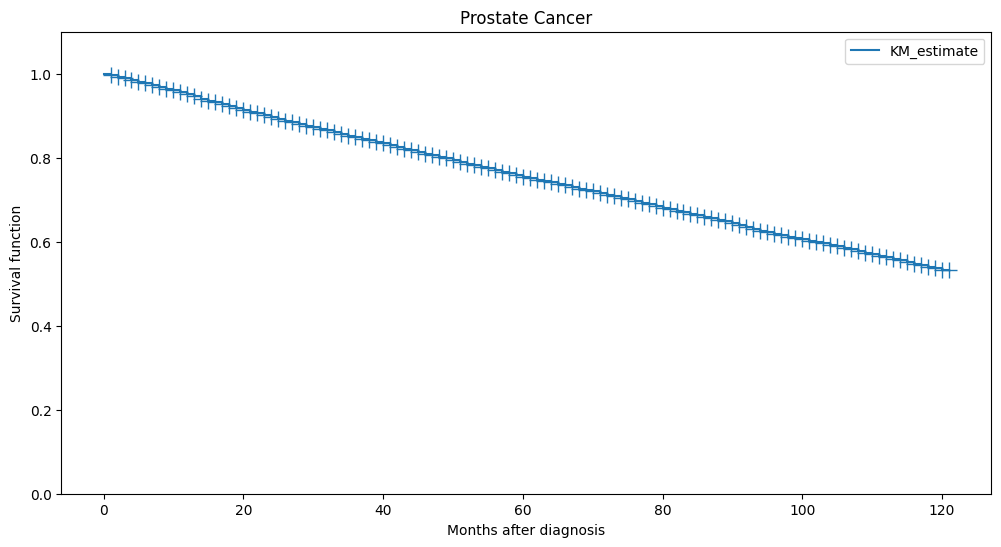

In [ ]:
# Kaplan-Meier Survival Curve Plot
# Extract event (E) and time (T) data from the test set
E = (df_teste.obito_geral == 1)  # Event indicator (obito_geral = 1 means event occurred)
T = df_teste.meses_diag  # Time to event (months since diagnosis)

title = f'Prostate Cancer'  # Set the plot title

kmf = KaplanMeierFitter()  # Initialize the Kaplan-Meier fitter

fig = plt.figure(figsize=(12, 6))  # Create the plot figure
ax = plt.subplot(111)  # Create the axes for the plot

# Fit and plot the Kaplan-Meier survival curve
ax = kmf.fit(T, E).plot(ax=ax, ci_show=False, show_censors=True)  # Fit the model, plot the curve, show censoring marks
ax.set_title(title)  # Set the plot title
ax.set_xlabel('Months after diagnosis')  # Set the x-axis label
ax.set_ylabel('Survival function')  # Set the y-axis label
plt.ylim([0, 1.1])  # Set y-axis limits
plt.show()  # Display the plot

In [ ]:
# Survival at 1, 3, 5, 7, and 10 Years
# Access survival probabilities at specific time points (12, 36, 60, 84, and 120 months)
kmf.survival_function_.loc[[12, 36, 60, 84, 120]]

,KM_estimate
timeline,
12.0,0.951600
36.0,0.849412
60.0,0.754361
84.0,0.667042
120.0,0.532856


## **Machine Learning Survival**

### **Data preparation for survival models**

In [ ]:
# Reading Training Data
df_treino = pd.read_csv('prostata_treino.csv')  # Load the training data from the CSV file
print(df_treino.shape)  # Print the dimensions of the training DataFrame
df_treino.head(3)  # Display the first 3 rows of the training DataFrame

(89124, 52)


,INSTITU,ESCOLARI,IDADE,IBGE,CATEATEND,DIAGPREV,MORFO,EC,ECGRUP,PSA,...,PRESENCA_META,PRESENCA_REC,obito_cancer,sobrevida_ano1,sobrevida_ano3,sobrevida_ano5,sobrevida_ano7,sobrevida_ano10,meses_diag,obito_geral
0,20141,2,73,3525904,2,2,85503,I,I,1,...,0,0,0,1,1,1,1,0,102,0
1,21636,4,70,3525300,2,1,85503,III,III,3,...,0,1,1,1,0,0,0,0,33,1
2,20737,2,62,3517406,2,2,85503,IIA,II,1,...,0,0,0,1,1,0,0,0,57,0


In [ ]:
# Reading Test Data
df_teste = pd.read_csv('prostata_teste.csv')  # Load the test data from the CSV file
print(df_teste.shape)  # Print the dimensions of the test DataFrame
df_teste.head(3)  # Display the first 3 rows of the test DataFrame

(22282, 52)


,INSTITU,ESCOLARI,IDADE,IBGE,CATEATEND,DIAGPREV,MORFO,EC,ECGRUP,PSA,...,PRESENCA_META,PRESENCA_REC,obito_cancer,sobrevida_ano1,sobrevida_ano3,sobrevida_ano5,sobrevida_ano7,sobrevida_ano10,meses_diag,obito_geral
0,15,9,67,3530508,2,1,85503,I,I,1,...,0,0,0,0,0,0,0,0,6,0
1,706637,4,62,3506508,2,2,85503,IIA,II,1,...,0,0,0,0,0,0,0,0,11,0
2,612374,3,73,3548708,2,2,85503,III,III,1,...,0,0,0,1,1,0,0,0,46,1


In [ ]:
# Y train and test for survival data (Death, Months from Diagnosis)
y_train = Surv.from_arrays(df_treino.obito_geral, df_treino.meses_diag)  # Create survival data for training set
y_test = Surv.from_arrays(df_teste.obito_geral, df_teste.meses_diag)  # Create survival data for test set

In [ ]:
# X train and test after removing unnecessary columns, including Death and Months from Diagnosis (which go to the target Y)
list_drop = ['sobrevida_ano1', 'sobrevida_ano3', 'sobrevida_ano5', 'sobrevida_ano7',
             'sobrevida_ano10', 'obito_geral', 'obito_cancer', 'ULTINFO', 'ULTIDIAG',
             'meses_diag', 'NENHUM', 'CIRURGIA', 'RADIO', 'QUIMIO', 'HORMONIO',
             'IMUNO', 'OUTROS', 'PRESENCA_META', 'PRESENCA_REC', 'PSA', 'GLEASON',
             'NENHUMAPOS', 'CIRURAPOS', 'RADIOAPOS', 'QUIMIOAPOS', 'HORMOAPOS',
             'IMUNOAPOS', 'OUTROAPOS', 'CONSDIAG', 'TRATCONS', 'DIAGTRAT',
             'RRAS', 'DSCINST', 'RRAS_INST', 'CONSDIAG_CAT', 'ECGRUP_CAT',
             'ECGRUP']

X_train = df_treino.drop(list_drop, axis=1)  # Remove specified columns from the training dataset

X_test = df_teste.drop(list_drop, axis=1)  # Remove specified columns from the test dataset

In [ ]:
# Preprocessing of Training and Test data
X_train, X_test, feat_cols, enc, norm = preprocessing(X_train, X_test,
                                                      norm_name='StandardScaler',  # Specify normalization method
                                                      return_enc_norm=True,  # Return encoder and normalizer objects
                                                      random_state=seed)  # Set random state for reproducibility

# Display the shapes of the processed training and test datasets
X_train.shape, X_test.shape

((89124, 15), (22282, 15))

In [ ]:
# Features columns
feat_cols

Index(['INSTITU', 'ESCOLARI', 'IDADE', 'IBGE', 'CATEATEND', 'DIAGPREV',
       'MORFO', 'EC', 'ANODIAG', 'DRS', 'IBGEATEN', 'HABILIT2', 'DRS_INST',
       'TRATCONS_CAT', 'DIAGTRAT_CAT'],
      dtype='object')

### **Random Survival Forest**

#### **Base Model**

In [ ]:
# RSF (Random Survival Forest) Model
rsf = RandomSurvivalForest(max_depth=11, n_jobs=-1, random_state=seed)  # Initialize the RSF model with a max depth of 11
rsf.fit(X_train, y_train)  # Train the model using the training data

# Calculate the C-index for the test dataset
c_index_base = rsf.score(X_test, y_test)

# Print the C-index for both test and training datasets
print(f'C-Index Test: {c_index_base}')
print(f'C-Index Train: {rsf.score(X_train, y_train)}')

C-Index Test: 0.7538377091593945
C-Index Train: 0.7665013864222648


C-Index IPCW Test: 0.7279855516241861
C-Index IPCW Train: 0.7435768576481568

Integrated Brier Score (IBS): 0.1308791045427077

Brier Score:
    > 1 year = 0.03860385482390669
    > 3 years = 0.10154530564400639
    > 5 years = 0.14470689931158354



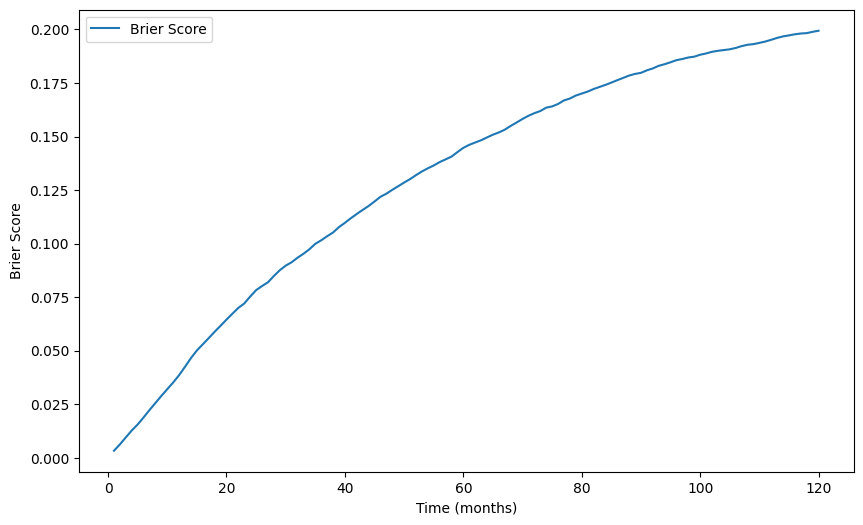

In [ ]:
# C-Index IPCW and Brier Score
c_index_ipcw_brier_score(rsf, X_train, y_train, X_test, y_test)  # Compute and evaluate the IPCW C-index and Brier Score

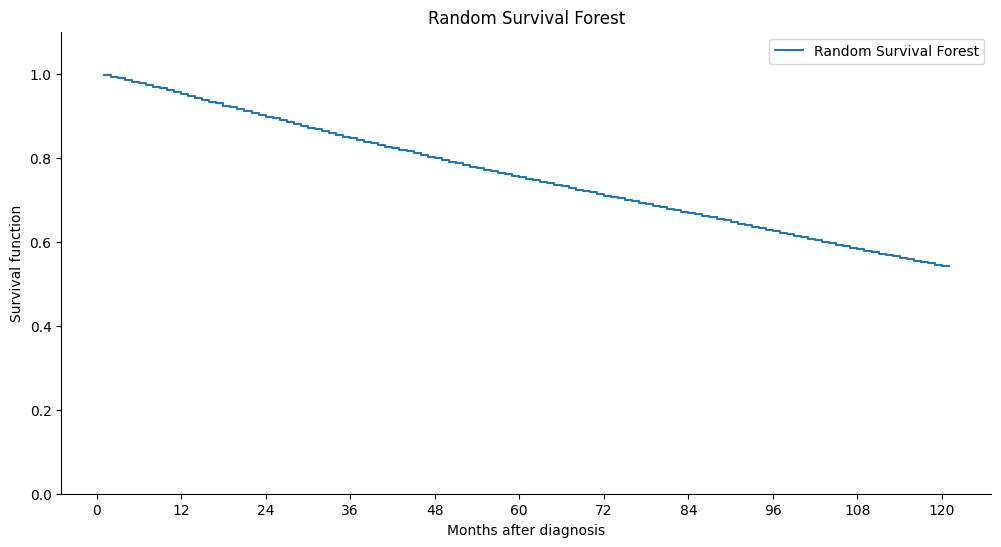

In [ ]:
# Survival prediction (Probability)
surv_rsf = rsf.predict_survival_function(X_test, return_array=True)  # Predict survival probabilities for the test set
surv_rsf_mean = surv_rsf.mean(axis=0)  # Compute the mean survival probability across samples

# Plot the predicted survival curve
name = 'Random Survival Forest'

plot_survival_curve(rsf.unique_times_, surv_rsf_mean, name=name)  # Generate and display the survival curve

In [ ]:
# Survival probability at 12, 36, 60, 84 and 120 months
print(f'12 months: {surv_rsf_mean[12]}')  # Print survival probability at 12 months
print(f'36 months: {surv_rsf_mean[36]}')  # Print survival probability at 36 months
print(f'60 months: {surv_rsf_mean[60]}')  # Print survival probability at 60 months
print(f'84 months: {surv_rsf_mean[84]}')  # Print survival probability at 84 months
print(f'120 months: {surv_rsf_mean[120]}')  # Print survival probability at 120 months

12 months: 0.9473964292872061
36 months: 0.842726475672886
60 months: 0.7495055845759898
84 months: 0.6649021158239138
120 months: 0.5423627028658039


#### **Optuna**

In [ ]:
# Optuna number of trials
n_trials = 150

In [ ]:
# Folds for cross-validation
kf = KFold(n_splits=10, shuffle=True, random_state=seed)  # Create a 10-fold cross-validation strategy

# Function to compute the C-index for a given estimator
def c_index(estimator, X, y):
    cindex = estimator.score(X, y)  # Compute the C-index score
    return cindex

# Objective function for hyperparameter optimization
def objective(trial):
    # Define hyperparameters to be optimized
    n_estimators = trial.suggest_int('n_estimators', 50, 150)  # Number of trees in the forest
    max_depth = trial.suggest_int('max_depth', 5, 12)  # Maximum depth of each tree
    min_samples_split = trial.suggest_int('min_samples_split', 3, 12)  # Min samples required to split a node
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 3, 12)  # Min samples required at a leaf node
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.5, 0.75, 1.0])  # Feature selection strategy
    bootstrap = trial.suggest_categorical('bootstrap', [True, False])  # Whether to use bootstrap sampling

    # Create and train the model with the suggested hyperparameters
    rsf = RandomSurvivalForest(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        bootstrap=bootstrap,
        random_state=seed,
        n_jobs=-1
    )

    # Perform cross-validation and return the mean C-index score
    return cross_val_score(rsf, X_train, y_train, cv=kf, scoring=c_index).mean()

**RandomSampler**

In [ ]:
%%time
# Pickle filename to save the study
pickle_filename = 'prost_opt_rsf_rand.pkl'

# Load existing study or create a new one
if os.path.exists(pickle_filename):
    with open(pickle_filename, 'rb') as f:
        study = pickle.load(f)
else:
    study = optuna.create_study(direction='maximize', sampler=RandomSampler(seed=seed),
                                study_name='RSF_RandomSampler')

# Total number of desired trials
completed_trials = len(study.trials)

# Execute remaining trials in batches
while completed_trials < n_trials:
    study.optimize(objective, n_trials=50, n_jobs=-1)
    completed_trials = len(study.trials)
    print(f"\nTrials completed: {completed_trials}/{n_trials}")

    # Save the study after each batch
    with open(pickle_filename, 'wb') as f:
        pickle.dump(study, f)

CPU times: user 32.2 ms, sys: 61 µs, total: 32.2 ms
Wall time: 60.6 ms


In [ ]:
# Display the best hyperparameters found by Optuna
print('Best parameters:', study.best_params)  # Print the best hyperparameters after optimization

Best parameters: {'n_estimators': 123, 'max_depth': 12, 'min_samples_split': 4, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'bootstrap': False}


In [ ]:
# Training and metrics with the best hyperparameters
best_params = study.best_params  # Get the best parameters from the study
rsf_rand = RandomSurvivalForest(**best_params, random_state=seed)  # Initialize the RSF model with the best parameters
rsf_rand.fit(X_train, y_train)  # Train the model with the training data

# Compute the C-index for the test dataset
c_index_rand = rsf_rand.score(X_test, y_test)

# Print the C-index for both test and training datasets
print(f'C-Index Test: {c_index_rand}')
print(f'C-Index Train: {rsf_rand.score(X_train, y_train)}')

C-Index Test: 0.7556982034177848
C-Index Train: 0.773440394544197


**TPESampler**

In [ ]:
%%time
# Pickle filename to save the study
pickle_filename = 'prost_opt_rsf_tpe.pkl'

# Load existing study or create a new one
if os.path.exists(pickle_filename):
    with open(pickle_filename, 'rb') as f:
        study = pickle.load(f)
else:
    study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=seed),
                                study_name='RSF_TPESampler')

# Total number of desired trials
completed_trials = len(study.trials)

# Execute remaining trials in batches
while completed_trials < n_trials:
    study.optimize(objective, n_trials=50, n_jobs=-1)
    completed_trials = len(study.trials)
    print(f"\nTrials completed: {completed_trials}/{n_trials}")

    # Save the study after each batch
    with open(pickle_filename, 'wb') as f:
        pickle.dump(study, f)

CPU times: user 20.8 ms, sys: 0 ns, total: 20.8 ms
Wall time: 21.7 ms


In [ ]:
# Display the best hyperparameters found by Optuna
print('Best parameters:', study.best_params)  # Print the best hyperparameters after optimization

Best parameters: {'n_estimators': 106, 'max_depth': 12, 'min_samples_split': 5, 'min_samples_leaf': 9, 'max_features': 'log2', 'bootstrap': False}


In [ ]:
# Training and metrics with the best hyperparameters
best_params = study.best_params  # Get the best parameters from the study
rsf_tpe = RandomSurvivalForest(**best_params, random_state=seed)  # Initialize the RSF model with the best parameters
rsf_tpe.fit(X_train, y_train)  # Train the model with the training data

# Compute the C-index for the test dataset
c_index_tpe = rsf_tpe.score(X_test, y_test)

# Print the C-index for both test and training datasets
print(f'C-Index Test: {c_index_tpe}')
print(f'C-Index Train: {rsf_tpe.score(X_train, y_train)}')

C-Index Test: 0.7553337124535708
C-Index Train: 0.7741253768611503


**CmaEsSampler**

In [ ]:
%%time
# Pickle filename to save the study
pickle_filename = 'prost_opt_rsf_cma.pkl'

# Load existing study or create a new one
if os.path.exists(pickle_filename):
    with open(pickle_filename, 'rb') as f:
        study = pickle.load(f)
else:
    study = optuna.create_study(direction='maximize', sampler=CmaEsSampler(seed=seed),
                                study_name='RSF_CmaEsSampler')

# Total number of desired trials
completed_trials = len(study.trials)

# Execute remaining trials in batches
while completed_trials < n_trials:
    study.optimize(objective, n_trials=50, n_jobs=-1)
    completed_trials = len(study.trials)
    print(f"\nTrials completed: {completed_trials}/{n_trials}")

    # Save the study after each batch
    with open(pickle_filename, 'wb') as f:
        pickle.dump(study, f)

CPU times: user 18.8 ms, sys: 936 µs, total: 19.7 ms
Wall time: 19.5 ms


In [ ]:
# Display the best hyperparameters found by Optuna
print('Best parameters:', study.best_params)  # Print the best hyperparameters after optimization

Best parameters: {'n_estimators': 92, 'max_depth': 12, 'min_samples_split': 6, 'min_samples_leaf': 9, 'max_features': 'log2', 'bootstrap': False}


In [ ]:
# Training and metrics with the best hyperparameters
best_params = study.best_params  # Get the best parameters from the study
rsf_cma = RandomSurvivalForest(**best_params, random_state=seed)  # Initialize the RSF model with the best parameters
rsf_cma.fit(X_train, y_train)  # Train the model with the training data

# Compute the C-index for the test dataset
c_index_cma = rsf_cma.score(X_test, y_test)

# Print the C-index for both test and training datasets
print(f'C-Index Test: {c_index_cma}')
print(f'C-index Train: {rsf_cma.score(X_train, y_train)}')

C-Index Test: 0.7554414883642686
C-index Train: 0.7741492467288952


#### **Best Random Survival Forest Model**

In [ ]:
# Best RSF model
scores = [c_index_base, c_index_rand, c_index_tpe, c_index_cma]  # List of C-index scores for different models
models = [rsf, rsf_rand, rsf_tpe, rsf_cma]  # List of the corresponding models

# Find the index of the model with the highest C-index score
id_best_score = scores.index(max(scores))
best = models[id_best_score]  # Select the model with the best score

# Print the best model
print(best)

RandomSurvivalForest(bootstrap=False, max_depth=12, min_samples_leaf=10,
                     min_samples_split=4, n_estimators=123, random_state=1)


C-Index Test: 0.7556982034177848
C-Index Train: 0.773440394544197

C-Index IPCW Test: 0.7299776174005818
C-Index IPCW Train: 0.7514293640225654

Integrated Brier Score (IBS): 0.13032298268309347

Brier Score:
    > 1 year = 0.038537957299891214
    > 3 years = 0.10115870450067298
    > 5 years = 0.14394400996462517



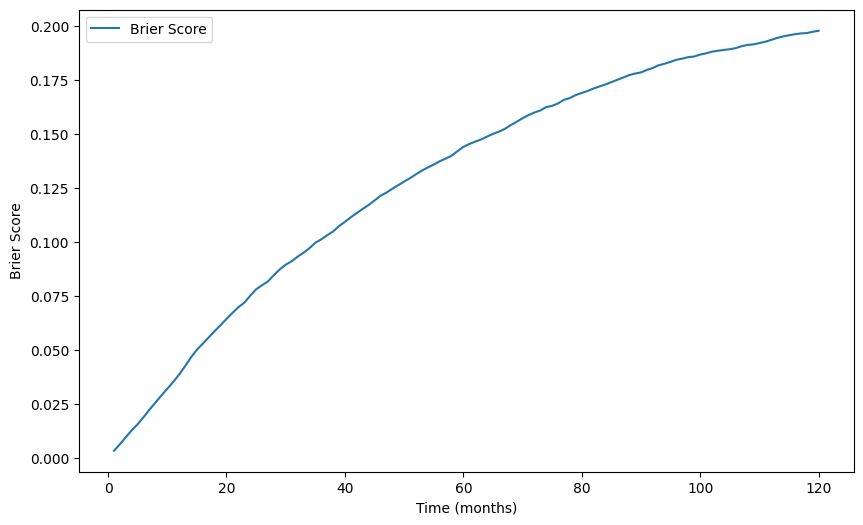

In [ ]:
# Metrics of the best RSF model
final_c_index = best.score(X_test, y_test)  # Compute the final C-index for the test dataset

# Print the C-index for both test and training datasets
print(f'C-Index Test: {final_c_index}')
print(f'C-Index Train: {best.score(X_train, y_train)}\n')

# Compute and display the IPCW C-index and Brier Score for the best model
c_index_ipcw_brier_score(best, X_train, y_train, X_test, y_test)

In [ ]:
# Best features by permutation importance
calculate_permutation_importance(best, X_test, y_test, feat_cols, random_state=seed)  # Calculate permutation importance of features for the best model

,importances_mean,importances_std
EC,0.104038,0.001405
IDADE,0.069868,0.001425
CATEATEND,0.011041,0.000508
DIAGTRAT_CAT,0.009551,0.000802
TRATCONS_CAT,0.007488,0.000884
INSTITU,0.005119,0.000269
ANODIAG,0.004384,0.000352
DRS_INST,0.004005,0.000489
MORFO,0.003895,0.000422
HABILIT2,0.003293,0.000252


PermutationExplainer explainer: 22283it [6:02:45,  1.02it/s]                             


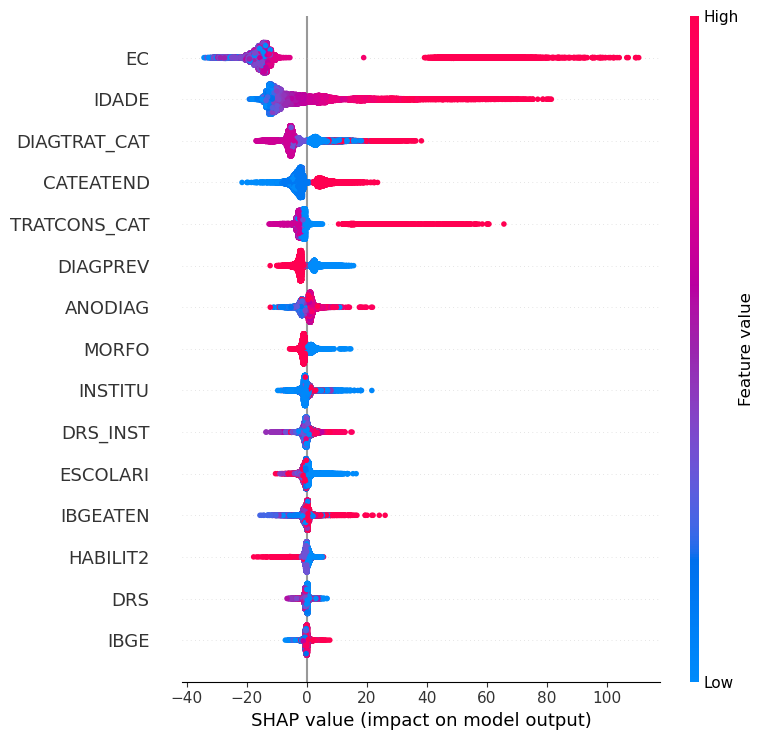

In [ ]:
# Best features by SHAP
explainer = shap.Explainer(best.predict, X_train, seed=seed,  # Create a SHAP explainer for the best model
                           output_names=feat_cols,  # Specify the feature names
                           n_jobs=-1)  # Use multiple jobs for parallel computation

shap_values = explainer(X_test)  # Calculate SHAP values for the test set

# Plot the SHAP summary plot to visualize feature importance
shap.summary_plot(shap_values, X_test, feature_names=feat_cols)

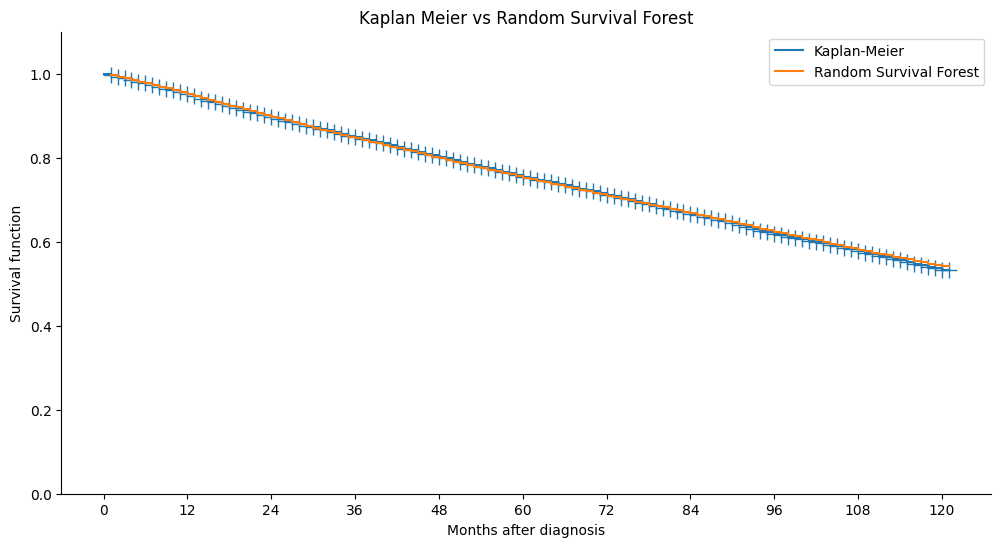

In [ ]:
# Comparison of survival curves
name = 'Random Survival Forest'  # Name of the model to be displayed on the plot

# Predict survival functions for the test set and compute the mean survival function
surv_rsf = best.predict_survival_function(X_test, return_array=True)
surv_rsf_mean = surv_rsf.mean(axis=0)  # Compute the mean survival function across all samples

# Plot the survival curve and compare with Kaplan-Meier (KM) estimates
plot_survival_curve(best.unique_times_, surv_rsf_mean,
                    name=name, compare_km=True, test_df=df_teste)  # Plot the survival curve and compare with the test dataset

### **Gradient Boosting Survival**

#### **Base Model**

In [ ]:
%%time
# GBS (Gradient Boosting Survival) Model
gb = GradientBoostingSurvivalAnalysis(n_estimators=100, max_depth=5,  # Initialize the GBS model with 100 estimators and a max depth of 5
                                      random_state=seed)  # Set the random state for reproducibility
gb.fit(X_train, y_train)  # Train the model using the training data

# Compute the C-index for the test dataset
c_index_base = gb.score(X_test, y_test)

# Print the C-index for both test and training datasets
print(f'C-Index Test: {c_index_base}')
print(f'C-Index Train: {gb.score(X_train, y_train)}')

C-Index Test: 0.7467511111901984
C-Index Train: 0.7437666164995745
CPU times: user 3h 23min 39s, sys: 329 ms, total: 3h 23min 39s
Wall time: 3h 24min 8s


C-Index IPCW Teste: 0.7236602454397717
C-Index IPCW Treino: 0.7236174805356468

Integrated Brier Score (IBS): 0.1327167960235387

Brier Score:
    > 1 ano = 0.03972908535708495
    > 3 anos = 0.10379522345208148
    > 5 anos = 0.14676293347678104



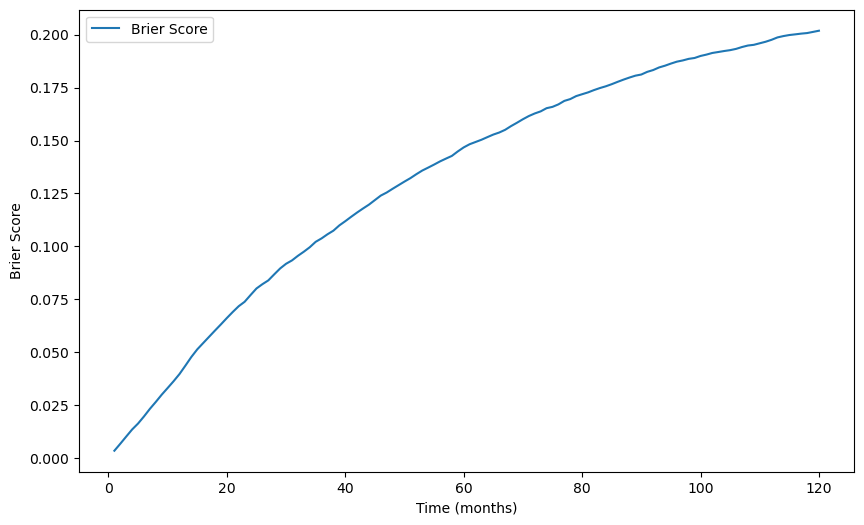

In [ ]:
# C-Index IPCW and Brier Score
c_index_ipcw_brier_score(gb, X_train, y_train, X_test, y_test)  # Compute and evaluate the IPCW C-index and Brier Score for the GBS model

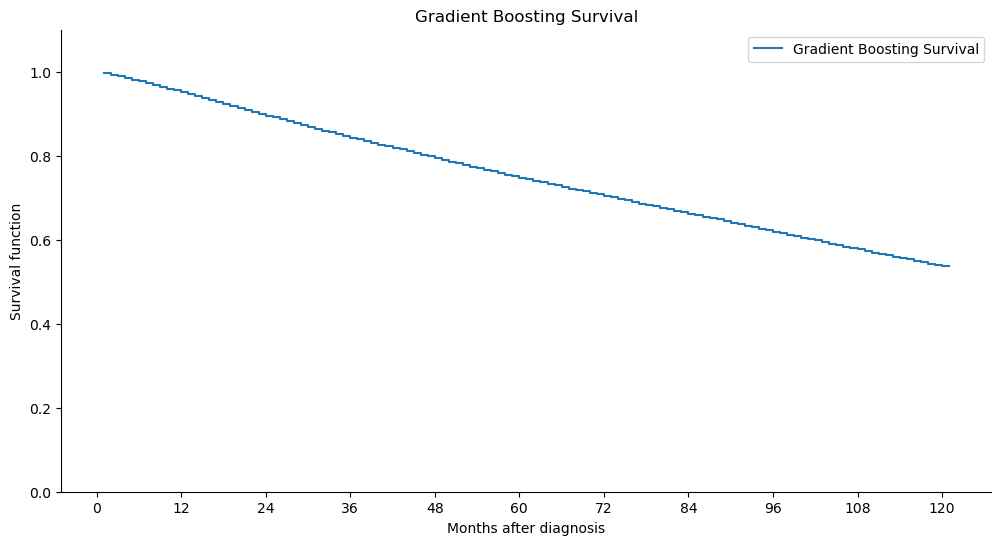

In [ ]:
# Survival function (Probability)
surv_gb = gb.predict_survival_function(X_test, return_array=True)  # Predict survival probabilities for the test set
surv_gb_mean = surv_gb.mean(axis=0)  # Compute the mean survival probability across samples

# Plot the predicted survival curve
name = 'Gradient Boosting Survival'

plot_survival_curve(gb.unique_times_, surv_gb_mean, name=name)  # Generate and display the survival curve

In [ ]:
# Survival probability at 12, 36, 60, 84, and 120 months
print(f'12 months: {surv_gb_mean[12]}')  # Print survival probability at 12 months
print(f'36 months: {surv_gb_mean[36]}')  # Print survival probability at 36 months
print(f'60 months: {surv_gb_mean[60]}')  # Print survival probability at 60 months
print(f'84 months: {surv_gb_mean[60]}')  # Print survival probability at 84 months
print(f'120 months: {surv_gb_mean[60]}')  # Print survival probability at 120 months

12 months: 0.9462326496171254
36 months: 0.839090370533504
60 months: 0.7438727345854644
84 months: 0.7438727345854644
120 months: 0.7438727345854644


#### **Optuna**

In [ ]:
# Optuna number of trials
n_trials = 100

In [ ]:
# Folds for cross-validation
kf = KFold(10, shuffle=True, random_state=seed)  # Create a 10-fold cross-validation strategy

# Function to compute the C-index for a given estimator
def c_index(estimator, X, y):
    cindex = estimator.score(X, y)  # Compute the C-index score
    return cindex

# Objective function for hyperparameter optimization
def objective(trial):
    # Define hyperparameters to be optimized
    n_estimators = trial.suggest_int('n_estimators', 50, 130)  # Number of boosting stages (trees)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.2, step=0.01)  # Learning rate for gradient boosting
    max_depth = trial.suggest_int('max_depth', 3, 7)  # Maximum depth of the individual trees
    min_samples_split = trial.suggest_int('min_samples_split', 2, 10)  # Minimum number of samples required to split an internal node
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 2, 10)  # Minimum number of samples required to be at a leaf node
    subsample = trial.suggest_float('subsample', 0.5, 1.0, step=0.1)  # Fraction of samples used for fitting each tree
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.5, 0.75, 1.0])  # Feature selection strategy for each tree

    # Create and train the model with the suggested hyperparameters
    gbsa = GradientBoostingSurvivalAnalysis(
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        subsample=subsample,
        max_features=max_features,
        random_state=seed
    )

    # Perform cross-validation and return the mean C-index score
    return cross_val_score(gbsa, X_train, y_train, cv=kf, scoring=c_index).mean()

**RandomSampler**

In [ ]:
%%time
# Pickle filename to save the study
pickle_filename = 'prost_opt_gbs_rand.pkl'

# Load existing study or create a new one
if os.path.exists(pickle_filename):
    with open(pickle_filename, 'rb') as f:
        study = pickle.load(f)
else:
    study = optuna.create_study(direction='maximize', sampler=RandomSampler(seed),
                                study_name='GBS_RandomSampler')

# Total number of desired trials
completed_trials = len(study.trials)

# Execute remaining trials in batches
while completed_trials < n_trials:
    study.optimize(objective, n_trials=50, n_jobs=-1)
    completed_trials = len(study.trials)
    print(f"\nTrials completed: {completed_trials}/{n_trials}")

    # Save the study after each batch
    with open(pickle_filename, 'wb') as f:
        pickle.dump(study, f)

CPU times: user 6.95 ms, sys: 989 µs, total: 7.94 ms
Wall time: 9.09 ms


In [ ]:
# Display the best hyperparameters found by Optuna
print('Best parameters:', study.best_params)  # Print the best parameters after optimization

Best parameters: {'n_estimators': 132, 'learning_rate': 0.13, 'max_depth': 8, 'min_samples_split': 10, 'min_samples_leaf': 7, 'subsample': 0.9, 'max_features': 'log2'}


In [ ]:
%%time
# Training and metrics with the best hyperparameters
best_params = study.best_params  # Get the best parameters from the study
gbsa_rand = GradientBoostingSurvivalAnalysis(**best_params, random_state=seed)  # Initialize the GBS model with the best parameters
gbsa_rand.fit(X_train, y_train)  # Train the model with the training data

# Compute the C-index for the test dataset
c_index_rand = gbsa_rand.score(X_test, y_test)

# Print the C-index for both test and training datasets
print(f'C-Index Test: {c_index_rand}')
print(f'C-Index Train: {gbsa_rand.score(X_train, y_train)}')

C-Index Test: 0.7571632681692106
C-Index Train: 0.7719286536839997
CPU times: user 4h 49min 49s, sys: 422 ms, total: 4h 49min 50s
Wall time: 4h 51min 11s


**TPESampler**

In [ ]:
%%time
# Pickle filename to save the study
pickle_filename = 'prost_opt_gbs_tpe.pkl'

# Load existing study or create a new one
if os.path.exists(pickle_filename):
    with open(pickle_filename, 'rb') as f:
        study = pickle.load(f)
else:
    study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=seed),
                                study_name='GBS_TPESampler')

# Total number of desired trials
completed_trials = len(study.trials)

# Execute remaining trials in batches
while completed_trials < n_trials:
    study.optimize(objective, n_trials=50, n_jobs=-1)
    completed_trials = len(study.trials)
    print(f"\nTrials completed: {completed_trials}/{n_trials}")

    # Save the study after each batch
    with open(pickle_filename, 'wb') as f:
        pickle.dump(study, f)

CPU times: user 8.51 ms, sys: 986 µs, total: 9.5 ms
Wall time: 10.4 ms


In [ ]:
# Display the best hyperparameters found by Optuna
print('Best parameters:', study.best_params)  # Print the best parameters after optimization

Best parameters: {'n_estimators': 147, 'learning_rate': 0.17, 'max_depth': 7, 'min_samples_split': 6, 'min_samples_leaf': 5, 'subsample': 0.9, 'max_features': 'log2'}


In [ ]:
%%time
# Training and metrics with the best hyperparameters
best_params = study.best_params  # Get the best parameters from the study
gbsa_tpe = GradientBoostingSurvivalAnalysis(**best_params, random_state=seed)  # Initialize the GBS model with the best parameters
gbsa_tpe.fit(X_train, y_train)  # Train the model with the training data

# Compute the C-index for the test dataset
c_index_tpe = gbsa_tpe.score(X_test, y_test)

# Print the C-index for both test and training datasets
print(f'C-Index Test: {c_index_tpe}')
print(f'C-Index Train: {gbsa_tpe.score(X_train, y_train)}')

C-Index Test: 0.7574227078105239
C-Index Train: 0.7688983492445585
CPU times: user 5h 22min 56s, sys: 458 ms, total: 5h 22min 56s
Wall time: 5h 24min 10s


**CmaEsSampler**

In [ ]:
%%time
# Pickle filename to save the study
pickle_filename = 'prost_opt_gbs_cma.pkl'

# Load existing study or create a new one
if os.path.exists(pickle_filename):
    with open(pickle_filename, 'rb') as f:
        study = pickle.load(f)
else:
    study = optuna.create_study(direction='maximize', sampler=CmaEsSampler(seed=seed),
                                study_name='GBS_CmaEsSampler')

# Total number of desired trials
completed_trials = len(study.trials)

# Execute remaining trials in batches
while completed_trials < n_trials:
    study.optimize(objective, n_trials=50, n_jobs=-1)
    completed_trials = len(study.trials)
    print(f"\nTrials completed: {completed_trials}/{n_trials}")

    # Save the study after each batch
    with open(pickle_filename, 'wb') as f:
        pickle.dump(study, f)

CPU times: user 8.34 ms, sys: 991 µs, total: 9.33 ms
Wall time: 10.5 ms


In [ ]:
# Display the best hyperparameters found by Optuna
print('Best parameters:', study.best_params)  # Print the best parameters after optimization

Best parameters: {'n_estimators': 119, 'learning_rate': 0.2, 'max_depth': 7, 'min_samples_split': 6, 'min_samples_leaf': 3, 'subsample': 0.9, 'max_features': 'sqrt'}


In [ ]:
%%time
# Training and metrics with the best hyperparameters
best_params = study.best_params  # Get the best parameters from the study
gbsa_cma = GradientBoostingSurvivalAnalysis(**best_params, random_state=seed)  # Initialize the GBS model with the best parameters
gbsa_cma.fit(X_train, y_train)  # Train the model with the training data

# Compute the C-index for the test dataset
c_index_cma = gbsa_cma.score(X_test, y_test)

# Print the C-index for both test and training datasets
print(f'C-Index Test: {c_index_cma}')
print(f'C-Index Train: {gbsa_cma.score(X_train, y_train)}')

C-Index Test: 0.757302361869312
C-Index Train: 0.7681562845490999
CPU times: user 4h 9min 50s, sys: 428 ms, total: 4h 9min 50s
Wall time: 4h 10min 37s


#### **Best Gradient Boosting Survival Model**

In [ ]:
# Best GBS model
scores = [c_index_base, c_index_rand, c_index_tpe, c_index_cma]  # List of C-index scores for each model
models = [gb, gbsa_rand, gbsa_tpe, gbsa_cma]  # List of corresponding models

id_best_score = scores.index(max(scores))  # Find the index of the model with the highest C-index score
best = models[id_best_score]  # Select the best model based on the highest score

print(best)  # Print the best model

GradientBoostingSurvivalAnalysis(learning_rate=0.17, max_depth=7,
                                 max_features='log2', min_samples_leaf=5,
                                 min_samples_split=6, n_estimators=147,
                                 random_state=1, subsample=0.9)


C-Index Test: 0.7574143045031059
C-Index Train: 0.7689585528925252

C-Index IPCW Test: 0.7331554816901165
C-Index IPCW Train: 0.7485084143253526

Integrated Brier Score (IBS): 0.12980064356386709

Brier Score:
    > 1 year = 0.03923035906779923
    > 3 years = 0.10175746943844075
    > 5 years = 0.14341794606037386



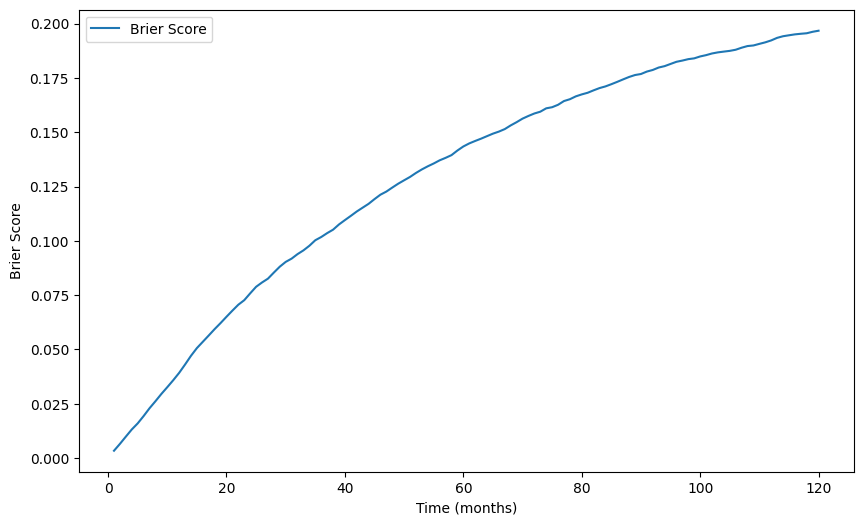

In [ ]:
# Metrics of the best GBS model
final_c_index = best.score(X_test, y_test)  # Compute the C-index for the best model on the test dataset

print(f'C-Index Test: {final_c_index}')  # Print the C-index for the test set
print(f'C-Index Train: {best.score(X_train, y_train)}\n')  # Print the C-index for the training set

# Calculate and print the IPCW and Brier score for the best model
c_index_ipcw_brier_score(best, X_train, y_train, X_test, y_test)

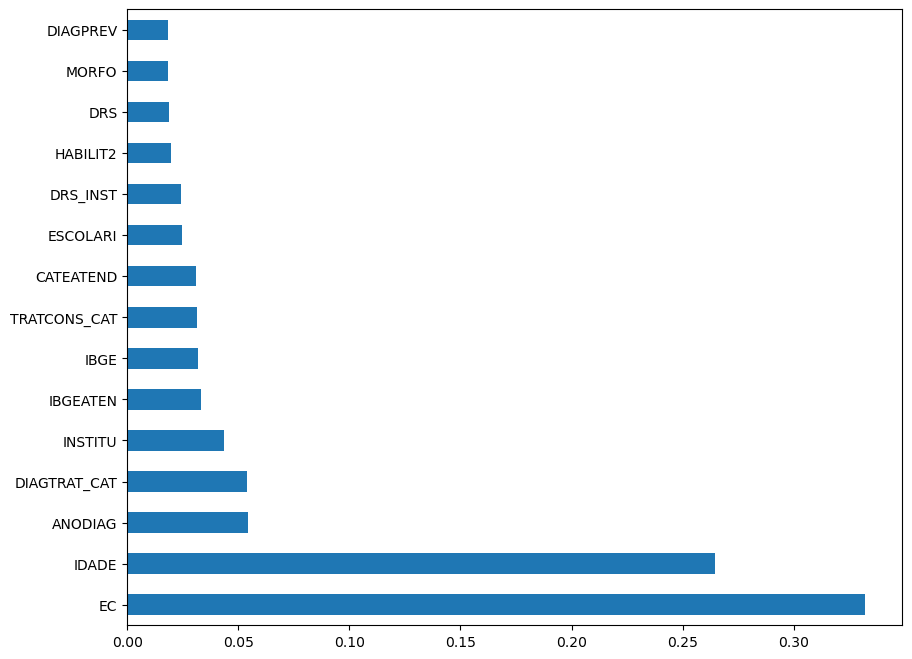

In [ ]:
# Feature Importances
feat_import = pd.Series(best.feature_importances_, index=feat_cols)  # Create a pandas Series with feature importances
feat_import.nlargest(15).plot(kind='barh', figsize=(10, 8))  # Plot the top 15 most important features as a horizontal bar chart
plt.show()  # Display the plot

In [ ]:
# Best features by permutation importance
calculate_permutation_importance(best, X_test, y_test, feat_cols, random_state=seed)  # Calculate permutation importance of features for the best model

,importances_mean,importances_std
EC,0.103445,0.001577
IDADE,0.077220,0.001722
CATEATEND,0.015093,0.000465
DIAGTRAT_CAT,0.009472,0.000728
ANODIAG,0.007937,0.000629
INSTITU,0.005104,0.000414
TRATCONS_CAT,0.004853,0.000556
IBGEATEN,0.003272,0.000356
DRS_INST,0.003136,0.000341
HABILIT2,0.002967,0.000284


PermutationExplainer explainer: 22283it [50:10,  7.38it/s]                           


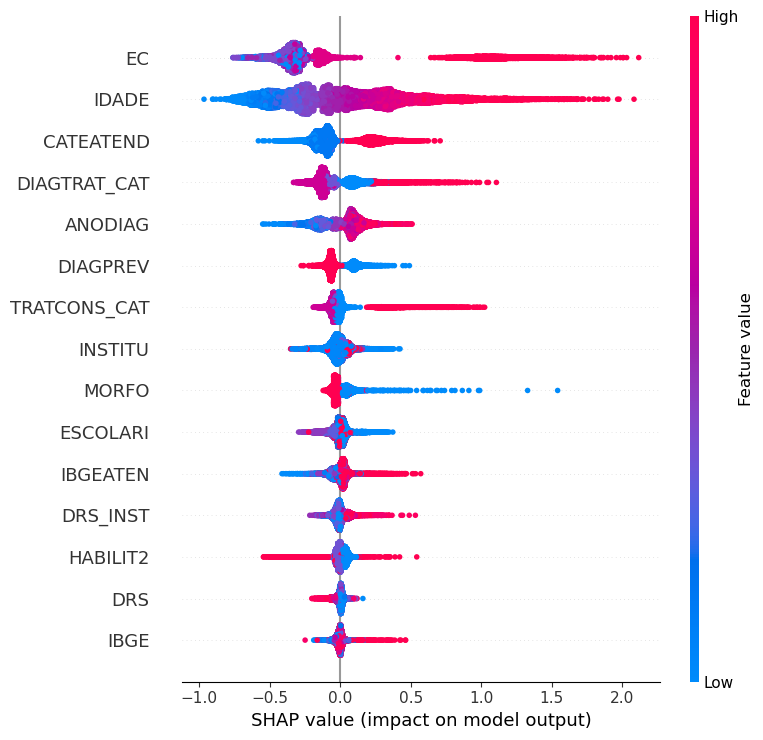

In [ ]:
# Best features by SHAP
explainer = shap.Explainer(best.predict, X_train, seed=seed,  # Create a SHAP explainer for the best model
                           output_names=feat_cols,  # Specify the feature names
                           n_jobs=-1)  # Use multiple jobs for parallel computation

shap_values = explainer(X_test)  # Calculate SHAP values for the test set

# Plot the SHAP summary plot to visualize feature importance
shap.summary_plot(shap_values, X_test, feature_names=feat_cols)

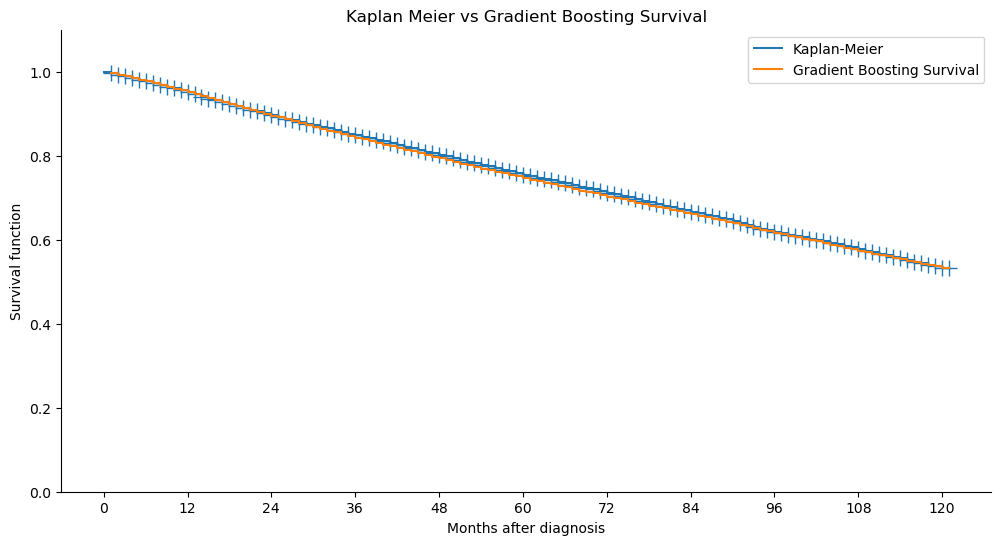

In [ ]:
# Comparison of survival curves
name = 'Gradient Boosting Survival'  # Set the name for the survival model

surv_gbs = best.predict_survival_function(X_test, return_array=True)  # Predict the survival function for the test set
surv_gbs_mean = surv_gbs.mean(axis=0)  # Compute the mean survival probability across the predictions

# Plot the survival curve and compare with the Kaplan-Meier curve
plot_survival_curve(best.unique_times_, surv_gbs_mean,
                    name=name, compare_km=True, test_df=df_teste)  # Visualize the survival curve with the comparison to the Kaplan-Meier estimate

### **Survival SVM**

#### **Base Model**

In [ ]:
# SurvivalSVM Model
ssvm = FastSurvivalSVM(random_state=seed)  # Initialize the FastSurvivalSVM model with a fixed random state

ssvm.fit(X_train, y_train)  # Train the model on the training data

c_index_base = ssvm.score(X_test, y_test)  # Calculate the C-index on the test dataset

# Print the C-index for both test and training datasets
print(f'C-Index Test: {c_index_base}')
print(f'C-Index Train: {ssvm.score(X_train, y_train)}')

C-Index Test: 0.7093987240925009
C-Index Train: 0.705069678285073


In [ ]:
# C-Index IPCW
surv_risks = ssvm.predict(X_test)  # Predict survival risks for the test dataset
surv_risks_train = ssvm.predict(X_train)  # Predict survival risks for the training dataset

# Calculate the IPCW C-index for both test and training datasets
c_index_ipcw = concordance_index_ipcw(y_train, y_test, surv_risks)
c_index_ipcw_train = concordance_index_ipcw(y_train, y_train, surv_risks_train)

# Print the IPCW C-index for both test and training datasets
print(f'C-Index IPCW Test: {c_index_ipcw[0]}')
print(f'C-Index IPCW Train: {c_index_ipcw_train[0]}')

C-Index IPCW Test: 0.6907096286653477
C-Index IPCW Train: 0.6883625355040631


#### **Optuna**

In [ ]:
# Optuna number of trials
n_trials = 150

In [ ]:
# Folds for cross-validation
kf = KFold(10, shuffle=True, random_state=seed)  # Create a KFold cross-validator with 10 splits, shuffling, and a fixed random seed

def c_index(estimator, X, y):
    cindex = estimator.score(X, y)  # Compute the C-index of the estimator on the dataset
    return cindex

def objective(trial):
    # Define hyperparameters to be optimized
    param = {
        'alpha': trial.suggest_categorical('alpha', [1e-3, 1e-2, 1e-1, 1, 10]),  # Suggest different values for the alpha regularization parameter
        'rank_ratio': trial.suggest_float('rank_ratio', 0.1, 1.0, step=0.05),  # Suggest a value for the rank ratio
        'tol': trial.suggest_categorical('tol', [1e-5, 1e-4, 1e-3, 1e-2]),  # Suggest tolerance values for convergence
    }

    # Train the model with the suggested parameters
    ssvm = FastSurvivalSVM(**param, random_state=seed)

    return cross_val_score(ssvm, X_train, y_train, cv=kf, scoring=c_index).mean()  # Return the mean cross-validated C-index score

**RandomSampler**

In [ ]:
%%time
# Filename for saving the pickle study
pickle_filename = 'prost_opt_svm_rand.pkl'

# Load the existing study or create a new one
if os.path.exists(pickle_filename):
    with open(pickle_filename, 'rb') as f:
        study = pickle.load(f)  # Load the study from the pickle file if it exists
else:
    study = optuna.create_study(direction='maximize', sampler=RandomSampler(seed),  # Create a new Optuna study
                                study_name='SSVM_RandomSampler')

# Total number of desired trials
completed_trials = len(study.trials)

# Execute remaining trials in blocks
while completed_trials < n_trials:
    study.optimize(objective, n_trials=50, n_jobs=-1)  # Optimize the objective function with 50 trials at a time
    completed_trials = len(study.trials)
    print(f"\nCompleted trials: {completed_trials}/{n_trials}")

    # Save the study after each block
    with open(pickle_filename, 'wb') as f:
        pickle.dump(study, f)  # Save the study object to a pickle file

CPU times: user 20.4 ms, sys: 0 ns, total: 20.4 ms
Wall time: 76.6 ms


In [ ]:
# Display the best hyperparameters found
print('Best parameters:', study.best_params)

Best parameters: {'alpha': 0.1, 'rank_ratio': 1.0, 'tol': 0.0001}


In [ ]:
# Training and metrics with the best hyperparameters
best_params = study.best_params
ssvm_rand = FastSurvivalSVM(**best_params, random_state=seed)  # Initialize the model with the best parameters
ssvm_rand.fit(X_train, y_train)  # Train the model on the training data

c_index_rand = ssvm_rand.score(X_test, y_test)  # Compute the C-index on the test data

# Print the C-index for both test and training datasets
print(f'C-Index Test: {c_index_rand}')
print(f'C-Index Train: {ssvm_rand.score(X_train, y_train)}')

C-Index Test: 0.7093964935233704
C-Index Train: 0.7050701871877026


**TPESampler**

In [ ]:
%%time
# Filename for saving the pickle study
pickle_filename = 'prost_opt_svm_tpe.pkl'

# Load the existing study or create a new one
if os.path.exists(pickle_filename):
    with open(pickle_filename, 'rb') as f:
        study = pickle.load(f)  # Load the study from the pickle file if it exists
else:
    study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=seed),  # Create a new Optuna study using TPE sampler
                                study_name='SSVM_TPESampler')

# Total number of desired trials
completed_trials = len(study.trials)

# Execute remaining trials in blocks
while completed_trials < n_trials:
    study.optimize(objective, n_trials=50, n_jobs=-1)  # Optimize the objective function with 50 trials at a time
    completed_trials = len(study.trials)
    print(f"\nCompleted trials: {completed_trials}/{n_trials}")

    # Save the study after each block
    with open(pickle_filename, 'wb') as f:
        pickle.dump(study, f)  # Save the study object to a pickle file

CPU times: user 21.3 ms, sys: 0 ns, total: 21.3 ms
Wall time: 22.8 ms


In [ ]:
# Display the best hyperparameters found
print('Best parameters:', study.best_params)

Best parameters: {'alpha': 0.01, 'rank_ratio': 1.0, 'tol': 0.0001}


In [ ]:
# Training and metrics with the best hyperparameters
best_params = study.best_params
ssvm_tpe = FastSurvivalSVM(**best_params, random_state=seed)  # Initialize the model with the best parameters
ssvm_tpe.fit(X_train, y_train)  # Train the model on the training data

c_index_tpe = ssvm_tpe.score(X_test, y_test)  # Compute the C-index on the test data

# Print the C-index for both test and training datasets
print(f'C-Index Test: {c_index_tpe}')
print(f'C-Index Train: {ssvm_tpe.score(X_train, y_train)}')

C-Index Test: 0.7093964935233704
C-Index Train: 0.7050701865651918


**CmaEsSampler**

In [ ]:
%%time
# Filename for saving the pickle study
pickle_filename = 'prost_opt_svm_cma.pkl'

# Load the existing study or create a new one
if os.path.exists(pickle_filename):
    with open(pickle_filename, 'rb') as f:
        study = pickle.load(f)  # Load the study from the pickle file if it exists
else:
    study = optuna.create_study(direction='maximize', sampler=CmaEsSampler(seed=seed),  # Create a new Optuna study using CMA-ES sampler
                                study_name='SSVM_CmaEsSampler')

# Total number of desired trials
completed_trials = len(study.trials)

# Execute remaining trials in blocks
while completed_trials < n_trials:
    study.optimize(objective, n_trials=50, n_jobs=-1)  # Optimize the objective function with 50 trials at a time
    completed_trials = len(study.trials)
    print(f"\nCompleted trials: {completed_trials}/{n_trials}")

    # Save the study after each block
    with open(pickle_filename, 'wb') as f:
        pickle.dump(study, f)  # Save the study object to a pickle file

CPU times: user 19.6 ms, sys: 0 ns, total: 19.6 ms
Wall time: 52.8 ms


In [ ]:
# Display the best hyperparameters found
print('Best parameters:', study.best_params)

Best parameters: {'alpha': 0.001, 'rank_ratio': 1.0, 'tol': 0.0001}


In [ ]:
# Training and metrics with the best hyperparameters
best_params = study.best_params
ssvm_cma = FastSurvivalSVM(**best_params, random_state=seed)  # Initialize the model with the best parameters
ssvm_cma.fit(X_train, y_train)  # Train the model on the training data

c_index_cma = ssvm_cma.score(X_test, y_test)  # Compute the C-index on the test data

# Print the C-index for both test and training datasets
print(f'C-Index Test: {c_index_cma}')
print(f'C-Index Train: {ssvm_cma.score(X_train, y_train)}')

C-Index Test: 0.7093964685729327
C-Index Train: 0.7050701874989581


#### **Best Survival SVM Model**

In [ ]:
# Best SSVM model
scores = [c_index_base, c_index_rand, c_index_tpe, c_index_cma]  # List of C-index scores for different models
models = [ssvm, ssvm_rand, ssvm_tpe, ssvm_cma]  # List of corresponding SSVM models

id_best_score = scores.index(max(scores))  # Identify the index of the model with the highest C-index score
best = models[id_best_score]  # Select the model with the best performance

print(best)  # Print the best model

FastSurvivalSVM(optimizer='avltree', random_state=1)


In [ ]:
# C-Index Calculation
print('C-Index')
print(f'> Test: {best.score(X_test, y_test)}')  # Calculate and print the C-index for the test set
print(f'> Train: {best.score(X_train, y_train)}')  # Calculate and print the C-index for the training set

# C-Index IPCW Calculation
surv_risks = best.predict(X_test)  # Predict survival risks for the test set
surv_risks_train = best.predict(X_train)  # Predict survival risks for the training set

# Compute IPCW C-index for test and train sets
c_index_ipcw = concordance_index_ipcw(y_train, y_test, surv_risks)  # IPCW C-index for the test set
c_index_ipcw_train = concordance_index_ipcw(y_train, y_train, surv_risks_train)  # IPCW C-index for the train set

print('\nC-Index IPCW')
print(f'> Test: {c_index_ipcw[0]}')  # Print the IPCW C-index for the test set
print(f'> Train: {c_index_ipcw_train[0]}')  # Print the IPCW C-index for the training set

C-Index
> Test: 0.7093987240925009
> Train: 0.705069678285073

C-Index IPCW
> Test: 0.6907096286653477
> Train: 0.6883625355040631


Brier Score at 12 months: 0.04509715118051345
Brier Score at 36 months: 0.11780966555944393
Brier Score at 60 months: 0.1651285251782385
Brier Score at 84 months: 0.19453961113704174
Brier Score at 120 months: 0.21842032083381333

Integrated Brier Score (IBS): 0.14785045060833735


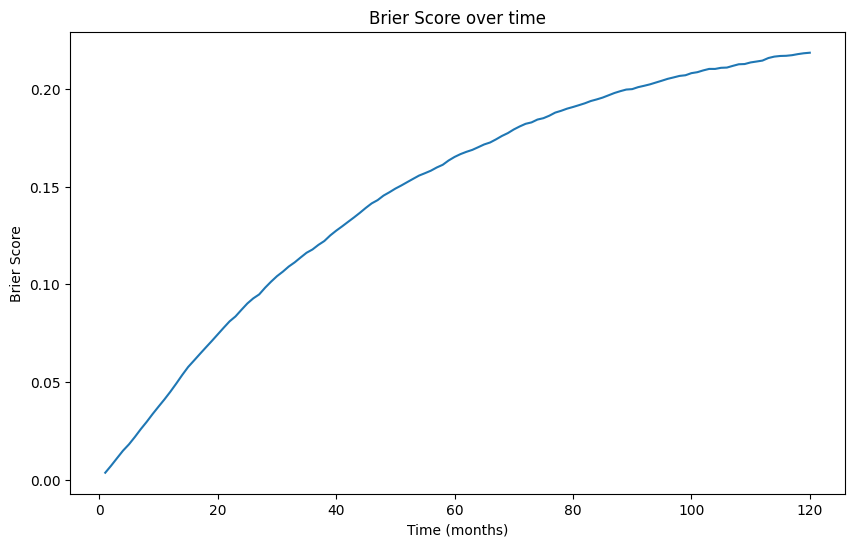

In [ ]:
from scipy.interpolate import interp1d

# Center and standardize the risks (avoid min-max normalization)
scaler = StandardScaler()
surv_risks_scaled = scaler.fit_transform(surv_risks.reshape(-1, 1)).flatten()

# Convert risks to hazard ratios (if the SSVM returns log-hazard values)
hazard_ratio = np.exp(surv_risks_scaled)  # Adjust this conversion as needed based on the model output

# Calculate the baseline survival curve on the training data using the Kaplan-Meier estimator
time_train, survival_prob_train = kaplan_meier_estimator(
    y_train["event"],
    y_train["time"]
)

# Compute the smoothed baseline hazard by taking the negative logarithm of the survival probability
baseline_hazard = -np.log(survival_prob_train + 1e-8)  # Add a small constant to avoid log(0)
baseline_hazard = np.nan_to_num(baseline_hazard, nan=0.0, posinf=0.0)  # Replace NaNs and infinities with 0

# Calculate S(t) = exp(-HR * H0(t)) for the test set, where HR is the hazard ratio and H0(t) is the baseline hazard
survival_probs_test = np.exp(-hazard_ratio[:, np.newaxis] * baseline_hazard)

# Define time points of interest (ensuring they fall within the observed range)
time_points = np.arange(1, 121, 1)  # From 1 to 60 months

# Perform stepwise interpolation (similar to Kaplan-Meier step functions)
interp_func = interp1d(
    time_train,
    survival_probs_test,
    kind='previous',  # Important for maintaining a step function behavior
    axis=1,
    bounds_error=False,
    fill_value=(1.0, 0.0)  # Conservative extrapolation: 1.0 before and 0.0 after the known range
)

# Obtain the interpolated survival probabilities for the defined time points
surv_probs_interp = interp_func(time_points)

# Enforce monotonicity: ensure survival probabilities do not increase over time
surv_probs_interp = np.minimum.accumulate(surv_probs_interp, axis=1)

# Clip values to ensure they are within valid bounds [0, 1]
surv_probs_final = np.clip(surv_probs_interp, 0.0, 1.0)

# Calculate the Brier Score at the specified time points
brier_scores = brier_score(
    y_train,  # Training data used to estimate censoring
    y_test,   # Test data
    surv_probs_final,
    time_points
)

# Calculate the Integrated Brier Score (IBS) over the entire time range
ibs = integrated_brier_score(
    y_train,
    y_test,
    surv_probs_final,
    time_points
)

# Print the Brier Score at specific time points: 12, 36, 60, 84, and 120 months
print(f"Brier Score at 12 months: {brier_scores[1][11]}")
print(f"Brier Score at 36 months: {brier_scores[1][35]}")
print(f"Brier Score at 60 months: {brier_scores[1][59]}")
print(f"Brier Score at 84 months: {brier_scores[1][83]}")
print(f"Brier Score at 120 months: {brier_scores[1][119]}")
print(f"\nIntegrated Brier Score (IBS): {ibs}")

# Plot the Brier Score over time
plt.figure(figsize=(10, 6))
plt.plot(time_points, brier_scores[1])
plt.xlabel("Time (months)")
plt.ylabel("Brier Score")
plt.title("Brier Score over time")
plt.show()

In [ ]:
# Best features by permutation importance
calculate_permutation_importance(best, X_test, y_test, feat_cols, random_state=seed)  # Calculate permutation importance of features for the best model

,importances_mean,importances_std
EC,8.654204e-02,0.002099
IDADE,8.394724e-02,0.002065
CATEATEND,1.189341e-02,0.000543
DIAGPREV,6.427584e-03,0.000822
HABILIT2,3.955928e-03,0.000432
MORFO,3.040095e-03,0.000408
DIAGTRAT_CAT,1.697287e-03,0.000242
DRS,1.226821e-03,0.000206
ANODIAG,1.048862e-03,0.000417
INSTITU,8.233704e-04,0.000128


PermutationExplainer explainer: 22283it [06:48, 53.56it/s]                           


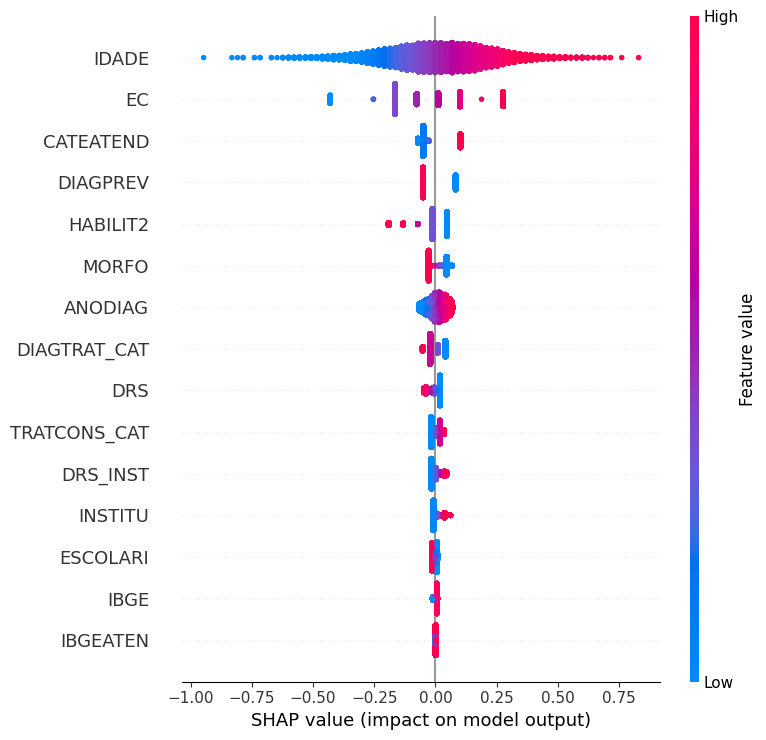

In [ ]:
# Best features by SHAP
explainer = shap.Explainer(best.predict, X_train, seed=seed,  # Create a SHAP explainer for the best model
                           output_names=feat_cols,  # Specify the feature names
                           n_jobs=-1)  # Use multiple jobs for parallel computation

shap_values = explainer(X_test)  # Calculate SHAP values for the test set

# Plot the SHAP summary plot to visualize feature importance
shap.summary_plot(shap_values, X_test, feature_names=feat_cols)

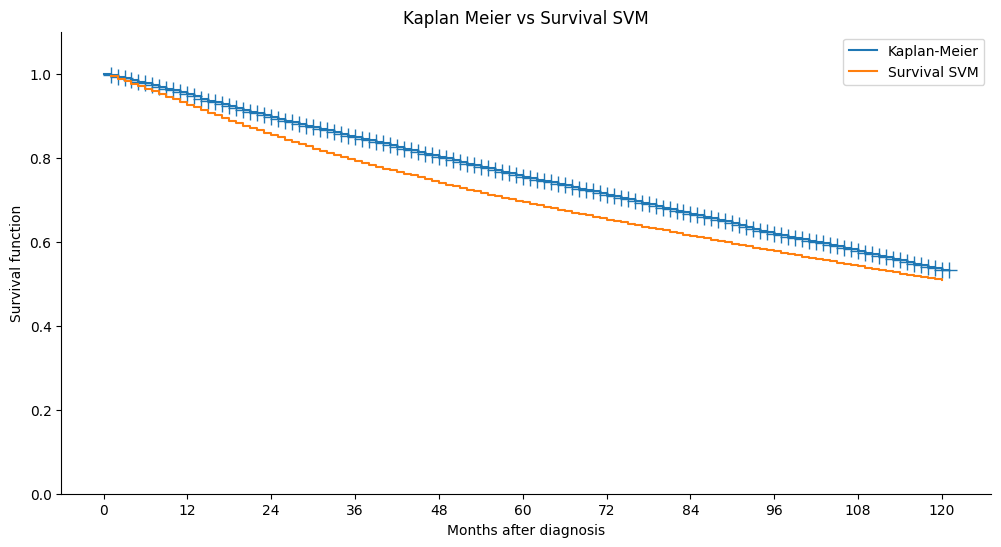

In [ ]:
# Survival Curve Plotting
name = 'Survival SVM'
fig = plt.figure(figsize=(12, 6))  # Create the plot figure
ax = plt.subplot(111)  # Create the axes for the plot

# Kaplan-Meier Comparison (if enabled)
E = (df_teste.obito_geral == 1)  # Extract event data (death)
T = df_teste.meses_diag  # Extract time-to-event data (months since diagnosis)

kmf = KaplanMeierFitter()  # Initialize Kaplan-Meier model
ax = kmf.fit(T, E).plot_survival_function(ax=ax, ci_show=False,  # Fit and plot Kaplan-Meier survival curve
                                          show_censors=True,  # Show censoring events
                                          label='Kaplan-Meier')  # Set label for the curve
title = f'Kaplan Meier vs {name}'  # Set title for comparison plot

# Plotting Model Survival Curve
surv_mean = surv_probs_final.mean(axis=0)  # Compute the mean survival function across all samples
ax.step(time_points, surv_mean, where='post', label=name)  # Plot the model's survival curve

# Plot Formatting
ax.set_title(title)  # Set the plot title
ax.set_xlabel('Months after diagnosis')  # Set x-axis label
ax.set_ylabel('Survival function')  # Set y-axis label
ax.spines['top'].set_visible(False)  # Remove top border
ax.spines['right'].set_visible(False)  # Remove right border
plt.xticks(np.arange(0, time_points[-1] + 11, 12))  # Set x-axis ticks every 12 months
plt.ylim([0, 1.1])  # Set y-axis limits
plt.legend();  # Show the legend

### **XGBoost - Cox**

#### **Base Model**

In [ ]:
# XGBoost Model
weights = np.where(y_train['event'], 1.0, 0.1)  # Assigning weights to the training data based on event status (1.0 for events, 0.15 for censored)

dtrain = xgb.DMatrix(X_train, label=y_train['time'], weight=weights)  # Prepare the training dataset for XGBoost, including weights and time as the target
dtest = xgb.DMatrix(X_test)  # Prepare the test dataset for prediction

# Training the XGBoost model for survival analysis
params = {
    'objective': 'survival:cox',  # Specify Cox proportional hazards objective for survival analysis
    'eval_metric': 'cox-nloglik',  # Use negative log-likelihood as the evaluation metric
    'max_depth': 5,  # Set the maximum depth of trees
    'seed': seed,  # Set random seed for reproducibility
}
xgboost = xgb.train(params, dtrain, num_boost_round=100)  # Train the XGBoost model with 100 boosting rounds

# Make predictions and calculate C-Index for Test data
y_pred = xgboost.predict(dtest)  # Predict survival times for the test set
c_index_base = concordance_index_censored(y_test['event'], y_test['time'], y_pred)[0]  # Calculate C-Index for the test data

# Make predictions and calculate C-Index for Training data
y_pred_train = xgboost.predict(dtrain)  # Predict survival times for the training set
c_index_train = concordance_index_censored(y_train['event'], y_train['time'], y_pred_train)[0]  # Calculate C-Index for the training data

# Display C-Index for Test and Train data
print(f'C-index Test: {c_index_base}')  # Print the C-Index for the test data
print(f'C-index Train: {c_index_train}')  # Print the C-Index for the training data

C-index Test: 0.6707189737090551
C-index Train: 0.6826666356855461


In [ ]:
# C-Index IPCW (Inverse Probability of Censoring Weight)
surv_risks = xgboost.predict(dtest)  # Predict the survival risks for the test set
surv_risks_train = xgboost.predict(dtrain)  # Predict the survival risks for the training set

# Calculate the C-Index IPCW for Test and Train data
c_index_ipcw = concordance_index_ipcw(y_train, y_test, surv_risks)  # Compute the C-Index IPCW for the test data
c_index_ipcw_train = concordance_index_ipcw(y_train, y_train, surv_risks_train)  # Compute the C-Index IPCW for the training data

# Display C-Index IPCW for Test and Train data
print(f'C-Index IPCW Test: {c_index_ipcw[0]}')  # Print the C-Index IPCW for the test data
print(f'C-Index IPCW Train: {c_index_ipcw_train[0]}')  # Print the C-Index IPCW for the training data

C-Index IPCW Test: 0.6604623646910915
C-Index IPCW Train: 0.6693353300767331


#### **Optuna**

In [ ]:
# Optuna number o trials
n_trials = 150

In [ ]:
# Folds for Cross-Validation
kf = KFold(10, shuffle=True, random_state=seed)  # Create 10-fold cross-validation with shuffling

def objective(trial):
    # Define the hyperparameters to be optimized
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 150),  # Number of estimators (trees)
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.25, step=0.01),  # Learning rate
        'max_depth': trial.suggest_int('max_depth', 3, 6),  # Maximum depth of trees
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),  # Minimum weight of child nodes
        'subsample': trial.suggest_float('subsample', 0.5, 1.0, step=0.05),  # Fraction of data used for training
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0, step=0.05),  # Fraction of features used per tree
        'reg_alpha': trial.suggest_categorical('reg_alpha', [1e-4, 1e-3, 1e-2, 1e-1, 1, 10]),  # L1 regularization term
        'reg_lambda': trial.suggest_categorical('reg_lambda', [1e-4, 1e-3, 1e-2, 1e-1, 1, 10]),  # L2 regularization term
        'objective': 'survival:cox',  # Cox loss function for survival analysis
        'eval_metric': 'cox-nloglik',  # Evaluation metric for Cox model
        'random_state': seed,  # Seed for reproducibility
        'n_jobs': -1,  # Use all available cores for training
    }

    c_index_list = []  # List to store the C-index values from each fold

    # Loop over the folds in cross-validation
    for train_idx, valid_idx in kf.split(X_train):
        # Split the data into training and validation sets for the current fold
        X_t, X_v = X_train[train_idx], X_train[valid_idx]  # Split features
        y_t, y_v = y_train[train_idx], y_train[valid_idx]  # Split labels

        # Create DMatrix for training and validation (DMatrix is an optimized data structure for XGBoost)
        dtrain = xgb.DMatrix(X_t, label=y_t['time'], weight=np.where(y_t['event'], 1.0, 0.1))  # Set event weights
        dvalid = xgb.DMatrix(X_v)  # Validation DMatrix (no labels, predictions will be made)

        # Train the XGBoost model using the specified hyperparameters
        model = xgb.train(param, dtrain, num_boost_round=100, verbose_eval=False)  # Train model with 100 boosting rounds

        # Make predictions on the validation set
        pred_valid = model.predict(dvalid)

        # Calculate the Concordance Index (C-Index) for the validation fold
        c_index = concordance_index_censored(y_v['event'], y_v['time'], pred_valid)[0]
        c_index_list.append(c_index)  # Append the C-Index for this fold to the list

    # Return the average C-Index across all folds
    return np.mean(c_index_list)  # The objective function returns the mean C-Index from the cross-validation folds

**RandomSampler**

In [ ]:
# Hyperparameter optimization with Optuna - RandomSampler
study = optuna.create_study(direction='maximize', sampler=RandomSampler(seed),  # Create a study to maximize the objective function
                            study_name='XGB_RandomSampler')  # Study name

study.optimize(objective, n_trials=n_trials, n_jobs=-1)  # Run the optimization with 'n_trials' trials in parallel

In [ ]:
# Display the best hyperparameters found
print('Best parameters:', study.best_params)

Best parameters: {'n_estimators': 90, 'learning_rate': 0.14, 'max_depth': 6, 'min_child_weight': 5, 'subsample': 1.0, 'colsample_bytree': 1.0, 'reg_alpha': 0.01, 'reg_lambda': 0.0001}


In [ ]:
# Training and evaluation with the best hyperparameters
weights = np.where(y_train['event'], 1.0, 0.1)  # Assign higher weights to events (1.0 for event and 0.1 for non-event)

best_params = study.best_params  # Get the best parameters from the study
best_params.update({'objective': 'survival:cox',  # Cox loss function for survival analysis
                    'eval_metric': 'cox-nloglik',  # Evaluation metric for Cox model
                    'random_state': seed,  # Set the random seed for reproducibility
                    'n_jobs': -1})  # Use all available cores for training

# Prepare the DMatrix objects for training and testing data
dtrain = xgb.DMatrix(X_train, label=y_train['time'], weight=weights)  # DMatrix for training with weights
dtest = xgb.DMatrix(X_test)  # DMatrix for testing without labels

# Train the XGBoost model with the best parameters
xgb_rand = xgb.train(best_params, dtrain, num_boost_round=100,
                     verbose_eval=False)

# Make predictions on the test and training datasets
y_pred = xgb_rand.predict(dtest)  # Predictions on the test data
y_pred_train = xgb_rand.predict(dtrain)  # Predictions on the training data

# Calculate the Concordance Index (C-Index) for test and training predictions
c_index_rand = concordance_index_censored(y_test['event'], y_test['time'], y_pred)[0]  # C-Index for test
c_index_rand_train = concordance_index_censored(y_train['event'], y_train['time'], y_pred_train)[0]  # C-Index for train

# Print the C-Index values
print(f'C-Index Test: {c_index_rand}')  # C-Index for the test set
print(f'C-Index Train: {c_index_rand_train}')  # C-Index for the training set

C-Index Test: 0.6741421587915117
C-Index Train: 0.6927228408030693


**TPESampler**

In [ ]:
# Hyperparameter optimization with Optuna - TPESampler
study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=seed),  # Create a study with TPE sampler for optimization
                            study_name='XGB_TPESampler')  # Study name for identification

study.optimize(objective, n_trials=n_trials, n_jobs=-1)  # Run optimization for 'n_trials' trials using parallel processing

In [ ]:
# Display the best hyperparameters found during optimization
print('Best parameters:', study.best_params)

Best parameters: {'n_estimators': 102, 'learning_rate': 0.09999999999999999, 'max_depth': 6, 'min_child_weight': 5, 'subsample': 1.0, 'colsample_bytree': 0.65, 'reg_alpha': 0.01, 'reg_lambda': 0.01}


In [ ]:
# Training and evaluation with the best hyperparameters
weights = np.where(y_train['event'], 1.0, 0.1)  # Assign higher weights to events (1.0 for event and 0.1 for non-event)
best_params = study.best_params  # Retrieve the best parameters from the study
best_params.update({'objective': 'survival:cox',  # Cox loss function for survival analysis
                    'eval_metric': 'cox-nloglik',  # Evaluation metric for Cox model
                    'random_state': seed,  # Set the random seed for reproducibility
                    'n_jobs': -1})  # Use all available cores for training

# Prepare the DMatrix objects for training and testing data
dtrain = xgb.DMatrix(X_train, label=y_train['time'], weight=weights)  # DMatrix for training with weights
dtest = xgb.DMatrix(X_test)  # DMatrix for testing without labels

# Train the XGBoost model with the best parameters
xgb_tpe = xgb.train(best_params, dtrain, num_boost_round=100,
                    verbose_eval=False)

# Make predictions on the test and training datasets
y_pred = xgb_tpe.predict(dtest)  # Predictions on the test data
y_pred_train = xgb_tpe.predict(dtrain)  # Predictions on the training data

# Calculate the Concordance Index (C-Index) for test and training predictions
c_index_tpe = concordance_index_censored(y_test['event'], y_test['time'], y_pred)[0]  # C-Index for test
c_index_tpe_train = concordance_index_censored(y_train['event'], y_train['time'], y_pred_train)[0]  # C-Index for train

# Print the C-Index values
print(f'C-Index Test: {c_index_tpe}')  # C-Index for the test set
print(f'C-Index Train: {c_index_tpe_train}')  # C-Index for the training set

C-Index Test: 0.6746581338431898
C-Index Train: 0.6862638520517828


**CmaEsSampler**

In [ ]:
# Hyperparameter optimization with Optuna - CmaEsSampler
study = optuna.create_study(direction='maximize', sampler=CmaEsSampler(seed=seed),  # Create a study with CMA-ES sampler for optimization
                            study_name='XGB_CmaEsSampler')  # Study name for identification

study.optimize(objective, n_trials=n_trials, n_jobs=-1)  # Run optimization for 'n_trials' trials using parallel processing

In [ ]:
# Display the best hyperparameters found during optimization
print('Best parameters:', study.best_params)

Best parameters: {'n_estimators': 115, 'learning_rate': 0.14, 'max_depth': 6, 'min_child_weight': 6, 'subsample': 1.0, 'colsample_bytree': 0.65, 'reg_alpha': 0.01, 'reg_lambda': 0.1}


In [ ]:
# Training and evaluation with the best hyperparameters
weights = np.where(y_train['event'], 1.0, 0.1)  # Assign higher weights to events (1.0 for event and 0.1 for non-event)

best_params = study.best_params  # Retrieve the best parameters from the study
best_params.update({'objective': 'survival:cox',  # Cox loss function for survival analysis
                    'eval_metric': 'cox-nloglik',  # Evaluation metric for Cox model
                    'random_state': seed,  # Set the random seed for reproducibility
                    'n_jobs': -1})  # Use all available cores for training

# Prepare the DMatrix objects for training and testing data
dtrain = xgb.DMatrix(X_train, label=y_train['time'], weight=weights)  # DMatrix for training with weights
dtest = xgb.DMatrix(X_test)  # DMatrix for testing without labels

# Train the XGBoost model with the best parameters
xgb_cma = xgb.train(best_params, dtrain, num_boost_round=100,
                    verbose_eval=False)

# Make predictions on the test and training datasets
y_pred = xgb_cma.predict(dtest)  # Predictions on the test data
y_pred_train = xgb_cma.predict(dtrain)  # Predictions on the training data

# Calculate the Concordance Index (C-Index) for test and training predictions
c_index_cma = concordance_index_censored(y_test['event'], y_test['time'], y_pred)[0]  # C-Index for test
c_index_cma_train = concordance_index_censored(y_train['event'], y_train['time'], y_pred_train)[0]  # C-Index for train

# Print the C-Index values
print(f'C-Index Test: {c_index_cma}')  # C-Index for the test set
print(f'C-Index Train: {c_index_cma_train}')  # C-Index for the training set

C-Index Test: 0.6744553316954602
C-Index Train: 0.6901451811303763


#### **Best XGBoost Model**

In [ ]:
# Best XGBoost model
scores = [c_index_base, c_index_rand, c_index_tpe, c_index_cma]  # List of C-index scores for each model
models = [xgboost, xgb_rand, xgb_tpe, xgb_cma]  # List of the trained models

# Find the model with the highest C-index
id_best_score = scores.index(max(scores))  # Get the index of the model with the best score
best = models[id_best_score]  # Select the best model based on the highest C-index

print(best)  # Display the best model

In [ ]:
# Make predictions on the validation and training sets
y_pred = best.predict(dtest)  # Predictions on the test set
y_pred_train = best.predict(dtrain)  # Predictions on the training set

# Calculate the C-Index for the test and training sets
final_c_index = concordance_index_censored(y_test['event'], y_test['time'], y_pred)[0]  # C-Index for the test set
final_c_index_train = concordance_index_censored(y_train['event'], y_train['time'], y_pred_train)[0]  # C-Index for the training set

print('C-Index')  # Print label for C-Index
print(f'> Test: {final_c_index}')  # Print C-Index for the test set
print(f'> Train: {final_c_index_train}')  # Print C-Index for the training set

c_index_ipcw = concordance_index_ipcw(y_train, y_test, y_pred)  # C-Index IPCW for the test set
c_index_ipcw_train = concordance_index_ipcw(y_train, y_train, y_pred_train)  # C-Index IPCW for the training set

print('\nC-Index IPCW')  # Print label for C-Index IPCW
print(f'> Test: {c_index_ipcw[0]}')  # Print IPCW C-Index for the test set
print(f'> Train: {c_index_ipcw_train[0]}')  # Print IPCW C-Index for the training set

C-Index
> Test: 0.6746581338431898
> Train: 0.6862638520517828

C-Index IPCW
> Test: 0.6645192857244641
> Train: 0.6735846705545412


Brier Score at 12 months: 0.04515476882198551
Brier Score at 36 months: 0.11893099834328533
Brier Score at 60 months: 0.1726333898632807
Brier Score at 84 months: 0.20759631365304582
Brier Score at 120 months: 0.23627531335471058

Integrated Brier Score (IBS): 0.15563059287520317


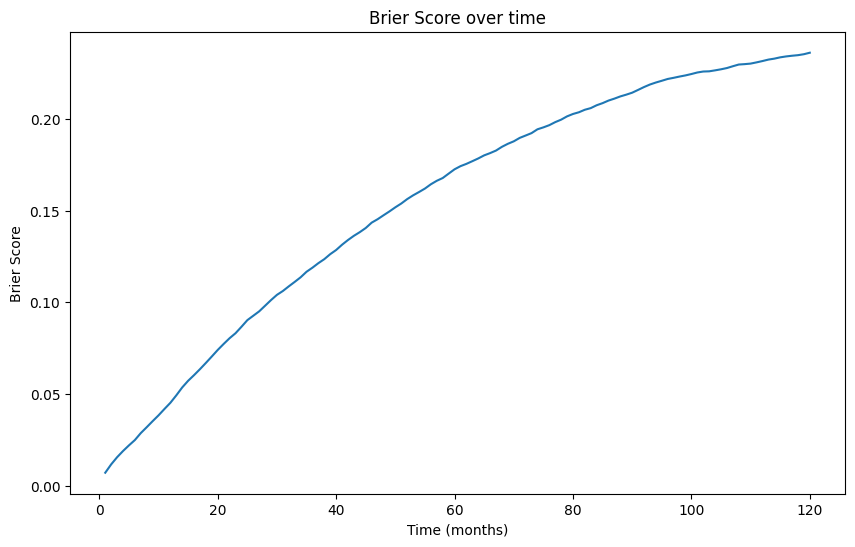

In [ ]:
# Center and standardize the risks (avoid min-max normalization)
scaler = StandardScaler()
surv_risks_scaled = scaler.fit_transform(y_pred.reshape(-1, 1)).flatten()

# Convert risks to hazard ratios (if the SSVM returns log-hazard values)
hazard_ratio = np.exp(surv_risks_scaled)  # Adjust this conversion as needed based on the model output

# Calculate the baseline survival curve on the training data using the Kaplan-Meier estimator
time_train, survival_prob_train = kaplan_meier_estimator(
    y_train["event"],
    y_train["time"]
)

# Compute the smoothed baseline hazard by taking the negative logarithm of the survival probability
baseline_hazard = -np.log(survival_prob_train + 1e-8)  # Add a small constant to avoid log(0)
baseline_hazard = np.nan_to_num(baseline_hazard, nan=0.0, posinf=0.0)  # Replace NaNs and infinities with 0

# Calculate S(t) = exp(-HR * H0(t)) for the test set, where HR is the hazard ratio and H0(t) is the baseline hazard
survival_probs_test = np.exp(-hazard_ratio[:, np.newaxis] * baseline_hazard)

# Define time points of interest (ensuring they fall within the observed range)
time_points = np.arange(1, 121, 1)  # From 1 to 120 months

# Perform stepwise interpolation (similar to Kaplan-Meier step functions)
interp_func = interp1d(
    time_train,
    survival_probs_test,
    kind='previous',  # Important for maintaining a step function behavior
    axis=1,
    bounds_error=False,
    fill_value=(1.0, 0.0)  # Conservative extrapolation: 1.0 before and 0.0 after the known range
)

# Obtain the interpolated survival probabilities for the defined time points
surv_probs_interp = interp_func(time_points)

# Enforce monotonicity: ensure survival probabilities do not increase over time
surv_probs_interp = np.minimum.accumulate(surv_probs_interp, axis=1)

# Clip values to ensure they are within valid bounds [0, 1]
surv_probs_final = np.clip(surv_probs_interp, 0.0, 1.0)

# Calculate the Brier Score at the specified time points
brier_scores = brier_score(
    y_train,  # Training data used to estimate censoring
    y_test,   # Test data
    surv_probs_final,
    time_points
)

# Calculate the Integrated Brier Score (IBS) over the entire time range
ibs = integrated_brier_score(
    y_train,  # Training data used to estimate censoring
    y_test,   # Test data
    surv_probs_final,
    time_points
)

# Print the Brier Score at specific time points: 12, 36, 60, 84, and 120 months
print(f"Brier Score at 12 months: {brier_scores[1][11]}")
print(f"Brier Score at 36 months: {brier_scores[1][35]}")
print(f"Brier Score at 60 months: {brier_scores[1][59]}")
print(f"Brier Score at 84 months: {brier_scores[1][83]}")
print(f"Brier Score at 120 months: {brier_scores[1][119]}")
print(f"\nIntegrated Brier Score (IBS): {ibs}")

# Plot the Brier Score over time
plt.figure(figsize=(10, 6))
plt.plot(time_points, brier_scores[1])
plt.xlabel("Time (months)")
plt.ylabel("Brier Score")
plt.title("Brier Score over time")
plt.show()

In [ ]:
# Best features by permutation importance
calculate_permutation_importance_xgb(best, X_test, y_test, feat_cols, random_state=seed)  # Calculate permutation importance of features for the best model

,importances_mean,importances_std
EC,0.077425,0.001117
ANODIAG,0.041021,0.002706
IDADE,0.040405,0.000772
CATEATEND,0.025972,0.000658
DIAGTRAT_CAT,0.015441,0.000860
INSTITU,0.009295,0.000757
TRATCONS_CAT,0.004728,0.000305
DIAGPREV,0.004672,0.000375
DRS_INST,0.004420,0.000364
MORFO,0.003882,0.000492


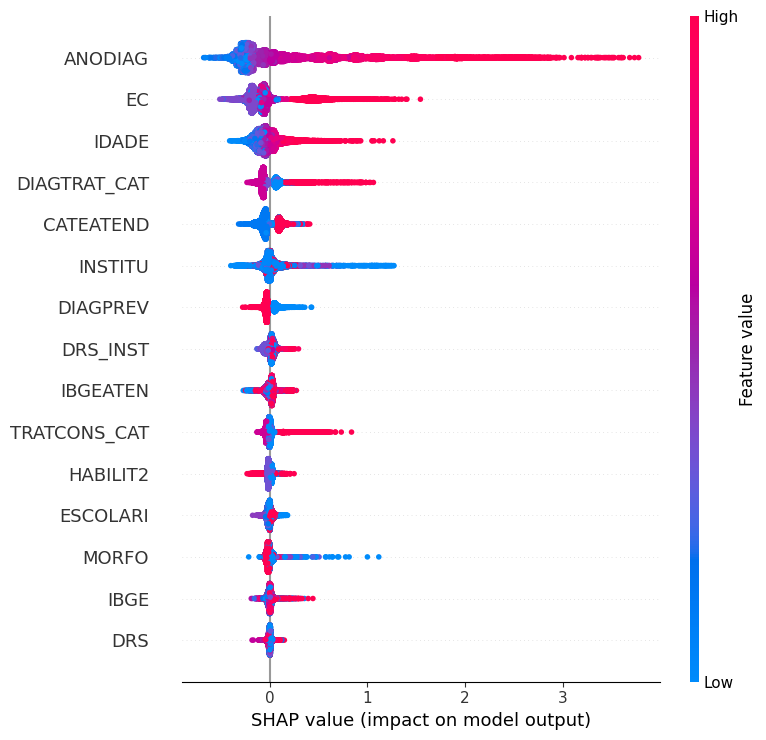

In [ ]:
# Create a SHAP TreeExplainer for the best model
explainer = shap.TreeExplainer(best)

# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test)

# Generate a summary plot to visualize the SHAP values for each feature
shap.summary_plot(shap_values, X_test, feature_names=feat_cols)

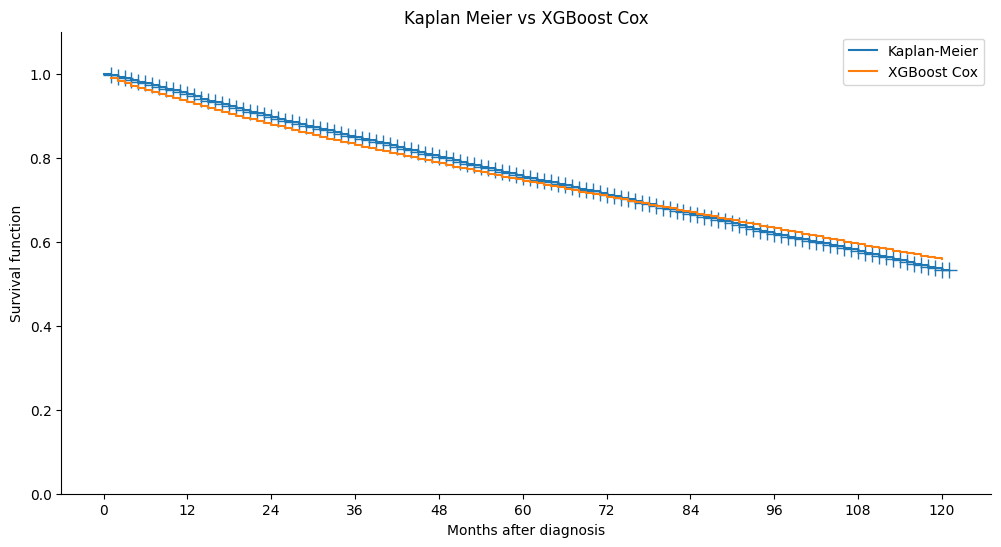

In [ ]:
# Survival Curve Plotting
name = 'XGBoost Cox'
fig = plt.figure(figsize=(12, 6))  # Create the plot figure
ax = plt.subplot(111)  # Create the axes for the plot

# Kaplan-Meier Comparison (if enabled)
E = (df_teste.obito_geral == 1)  # Extract event data (death)
T = df_teste.meses_diag  # Extract time-to-event data (months since diagnosis)

kmf = KaplanMeierFitter()  # Initialize Kaplan-Meier model
ax = kmf.fit(T, E).plot_survival_function(ax=ax, ci_show=False,  # Fit and plot Kaplan-Meier survival curve
                                          show_censors=True,  # Show censoring events
                                          label='Kaplan-Meier')  # Set label for the curve
title = f'Kaplan Meier vs {name}'  # Set title for comparison plot

# Plotting Model Survival Curve
surv_mean = surv_probs_final.mean(axis=0)  # Compute the mean survival function across all samples
ax.step(time_points, surv_mean, where='post', label=name)  # Plot the model's survival curve

# Plot Formatting
ax.set_title(title)  # Set the plot title
ax.set_xlabel('Months after diagnosis')  # Set x-axis label
ax.set_ylabel('Survival function')  # Set y-axis label
ax.spines['top'].set_visible(False)  # Remove top border
ax.spines['right'].set_visible(False)  # Remove right border
plt.xticks(np.arange(0, time_points[-1] + 11, 12))  # Set x-axis ticks every 12 months
plt.ylim([0, 1.1])  # Set y-axis limits
plt.legend();  # Show the legend

### **XGBoost - AFT**

#### **Base Model**

In [ ]:
# Define weights (1.0 for events, 0.5 for censored cases)
weights = np.where(y_train['event'], 1.0, 0.5)

# The AFT model requires lower and upper bounds for survival time
label_lower_bound = y_train['time']
label_upper_bound = np.where(y_train['event'], y_train['time'], np.inf)

# Creating DMatrix for XGBoost (necessary to define bounds for AFT)
dtrain = xgb.DMatrix(X_train,
                     label_lower_bound=label_lower_bound,
                     label_upper_bound=label_upper_bound,
                     weight=weights)

dtest = xgb.DMatrix(X_test)

# Configuration of hyperparameters for the XGBoost Survival AFT model
params = {
    'objective': 'survival:aft',  # Use AFT to model survival analysis
    'eval_metric': 'aft-nloglik',  # Evaluation metric for AFT
    'aft_loss_distribution': 'normal',  # Failure time distribution ('normal', 'logistic', etc.)
    'aft_loss_distribution_scale': 1.0,  # Scale of the distribution (adjustable)
    'max_depth': 4,  # Maximum depth of trees
    'seed': seed,  # Seed for reproducibility
}

# Model training
xgb_aft = xgb.train(params, dtrain, num_boost_round=100)

# Predictions and C-Index calculation for the test set
y_pred = xgb_aft.predict(dtest)
c_index_base = concordance_index_censored(y_test['event'], y_test['time'], -y_pred)[0]

# Predictions and C-Index calculation for the training set
y_pred_train = xgb_aft.predict(dtrain)
c_index_train = concordance_index_censored(y_train['event'], y_train['time'], -y_pred_train)[0]

# Display C-Index results
print(f'C-index Test: {c_index_base}')
print(f'C-index Train: {c_index_train}')

C-index Test: 0.7548692800160977
C-index Train: 0.7609957045798086


In [ ]:
# C-Index IPCW (Inverse Probability of Censoring Weight)
surv_risks = xgb_aft.predict(dtest)  # Predict the survival risks for the test set
surv_risks_train = xgb_aft.predict(dtrain)  # Predict the survival risks for the training set

# Calculate the C-Index IPCW for Test and Train data
c_index_ipcw = concordance_index_ipcw(y_train, y_test, -surv_risks)  # Compute the C-Index IPCW for the test data
c_index_ipcw_train = concordance_index_ipcw(y_train, y_train, -surv_risks_train)  # Compute the C-Index IPCW for the training data

# Display C-Index IPCW for Test and Train data
print(f'C-Index IPCW Test: {c_index_ipcw[0]}')  # Print the C-Index IPCW for the test data
print(f'C-Index IPCW Train: {c_index_ipcw_train[0]}')  # Print the C-Index IPCW for the training data

C-Index IPCW Test: 0.7279456677057946
C-Index IPCW Train: 0.7353129427181931


#### **Optuna**

In [ ]:
# Optuna number o trials
n_trials = 150

In [ ]:
# Folds for Cross-Validation
kf = KFold(10, shuffle=True, random_state=seed)  # Create 10-fold cross-validation with shuffling

def objective(trial):
    # Define the hyperparameters to be optimized
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 150),  # Number of estimators (trees)
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.25, step=0.01),  # Learning rate
        'max_depth': trial.suggest_int('max_depth', 2, 5),  # Maximum depth of trees
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),  # Minimum weight of child nodes
        'subsample': trial.suggest_float('subsample', 0.5, 1.0, step=0.05),  # Fraction of data used for training
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0, step=0.05),  # Fraction of features used per tree
        'reg_alpha': trial.suggest_categorical('reg_alpha', [1e-4, 1e-3, 1e-2, 1e-1, 1, 10]),  # L1 regularization term
        'reg_lambda': trial.suggest_categorical('reg_lambda', [1e-4, 1e-3, 1e-2, 1e-1, 1, 10]),  # L2 regularization term
        'aft_loss_distribution': trial.suggest_categorical('aft_loss_distribution', ['normal', 'logistic', 'extreme']),  # AFT Distribution Type
        'aft_loss_distribution_scale': trial.suggest_float('aft_loss_distribution_scale', 0.5, 2.0, step=0.05),  # AFT distribution scale
        'objective': 'survival:aft',  # AFT loss function for survival analysis
        'eval_metric': 'aft-nloglik',  # Evaluation metric for AFT model
        'random_state': seed,  # Seed for reproducibility
        'n_jobs': -1,  # Use all available cores for training
    }

    fold_c_indices = []  # List to store the C-index values from each fold

    # Loop over the folds in cross-validation
    for train_idx, valid_idx in kf.split(X_train):
        try:
            # Split the data into training and validation sets for the current fold
            X_t, X_v = X_train[train_idx], X_train[valid_idx]  # Split features
            y_t, y_v = y_train[train_idx], y_train[valid_idx]  # Split labels

            # Defining the lower and upper limits for AFT (survival time)
            label_lower_bound = y_t['time']
            label_upper_bound = np.where(y_t['event'], y_t['time'], np.inf)

            # Create DMatrix for training and validation (DMatrix is an optimized data structure for XGBoost)
            dtrain = xgb.DMatrix(X_t, label_lower_bound=label_lower_bound,
                                 label_upper_bound=label_upper_bound,
                                 weight=np.where(y_t['event'], 1.0, 0.5))  # Set event weights

            dvalid = xgb.DMatrix(X_v)  # Validation DMatrix (no labels, predictions will be made)

            # Train the XGBoost model using the specified hyperparameters
            model = xgb.train(param, dtrain, num_boost_round=100, verbose_eval=False)  # Train model with 100 boosting rounds

            # Make predictions on the validation set
            pred_valid = model.predict(dvalid)

            # Calculate the Concordance Index (C-Index) for the validation fold
            c_index = concordance_index_censored(y_v['event'],
                                                 y_v['time'],
                                                 -pred_valid)[0]
            fold_c_indices.append(c_index)  # Append the C-Index for this fold to the list

        except (ValueError, xgb.core.XGBoostError) as e:
            continue  # Next Fold

    # Return the average C-Index
    return np.nanmean(fold_c_indices)  # The objective function returns the mean C-Index from the cross-validation folds

**RandomSampler**

In [ ]:
# Hyperparameter optimization with Optuna - RandomSampler
study = optuna.create_study(direction='maximize', sampler=RandomSampler(seed),  # Create a study to maximize the objective function
                            study_name='XGB_RandomSampler')  # Study name

study.optimize(objective, n_trials=n_trials, n_jobs=-1)  # Run the optimization with 'n_trials' trials in parallel

In [ ]:
# Display the best hyperparameters found
print('Best parameters:', study.best_params)

Best parameters: {'n_estimators': 51, 'learning_rate': 0.16, 'max_depth': 5, 'min_child_weight': 7, 'subsample': 0.9, 'colsample_bytree': 0.5, 'reg_alpha': 1, 'reg_lambda': 0.0001, 'aft_loss_distribution': 'normal', 'aft_loss_distribution_scale': 1.4500000000000002}


In [ ]:
# Training and evaluation with the best hyperparameters
weights = np.where(y_train['event'], 1.0, 0.5)  # Assign higher weights to events (1.0 for event and 0.5 for non-event)

# The AFT model requires lower and upper bounds for survival time
label_lower_bound = y_train['time']
label_upper_bound = np.where(y_train['event'], y_train['time'], np.inf)

best_params = study.best_params  # Get the best parameters from the study
best_params.update({'objective': 'survival:aft',  # AFT loss function for survival analysis
                    'eval_metric': 'aft-nloglik',  # Evaluation metric for AFT model
                    'random_state': seed,  # Seed for reproducibility
                    'n_jobs': -1})  # Use all available cores for training

# Prepare the DMatrix objects for training and testing data
dtrain = xgb.DMatrix(X_train,
                     label_lower_bound=label_lower_bound,
                     label_upper_bound=label_upper_bound,
                     weight=weights)  # DMatrix for training with weights

dtest = xgb.DMatrix(X_test)  # DMatrix for testing without labels

# Train the XGBoost model with the best parameters
xgb_rand = xgb.train(best_params, dtrain, num_boost_round=100)

# Make predictions on the test and training datasets
y_pred = xgb_rand.predict(dtest)  # Predictions on the test data
y_pred_train = xgb_rand.predict(dtrain)  # Predictions on the training data

# Calculate the Concordance Index (C-Index) for test and training predictions
c_index_rand = concordance_index_censored(y_test['event'], y_test['time'], -y_pred)[0]  # C-Index for test
c_index_rand_train = concordance_index_censored(y_train['event'], y_train['time'], -y_pred_train)[0]  # C-Index for train

# Print the C-Index values
print(f'C-Index Test: {c_index_rand}')  # C-Index for the test set
print(f'C-Index Train: {c_index_rand_train}')  # C-Index for the training set

C-Index Test: 0.7570915606112549
C-Index Train: 0.762025574722057


**TPESampler**

In [ ]:
# Hyperparameter optimization with Optuna - TPESampler
study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=seed),  # Create a study with TPE sampler for optimization
                            study_name='XGB_TPESampler')  # Study name for identification

study.optimize(objective, n_trials=n_trials, n_jobs=-1)  # Run optimization for 'n_trials' trials using parallel processing

In [ ]:
# Display the best hyperparameters found during optimization
print('Best parameters:', study.best_params)

Best parameters: {'n_estimators': 125, 'learning_rate': 0.24000000000000002, 'max_depth': 5, 'min_child_weight': 4, 'subsample': 0.95, 'colsample_bytree': 0.8, 'reg_alpha': 1, 'reg_lambda': 10, 'aft_loss_distribution': 'extreme', 'aft_loss_distribution_scale': 0.9}


In [ ]:
# Training and evaluation with the best hyperparameters
weights = np.where(y_train['event'], 1.0, 0.5)  # Assign higher weights to events (1.0 for event and 0.5 for non-event)

# The AFT model requires lower and upper bounds for survival time
label_lower_bound = y_train['time']
label_upper_bound = np.where(y_train['event'], y_train['time'], np.inf)

best_params = study.best_params  # Get the best parameters from the study
best_params.update({'objective': 'survival:aft',  # AFT loss function for survival analysis
                    'eval_metric': 'aft-nloglik',  # Evaluation metric for AFT model
                    'random_state': seed,  # Seed for reproducibility
                    'n_jobs': -1})  # Use all available cores for training

# Prepare the DMatrix objects for training and testing data
dtrain = xgb.DMatrix(X_train,
                     label_lower_bound=label_lower_bound,
                     label_upper_bound=label_upper_bound,
                     weight=weights)  # DMatrix for training with weights

dtest = xgb.DMatrix(X_test)  # DMatrix for testing without labels

# Train the XGBoost model with the best parameters
xgb_tpe = xgb.train(best_params, dtrain, num_boost_round=100)

# Make predictions on the test and training datasets
y_pred = xgb_tpe.predict(dtest)  # Predictions on the test data
y_pred_train = xgb_tpe.predict(dtrain)  # Predictions on the training data

# Calculate the Concordance Index (C-Index) for test and training predictions
c_index_tpe = concordance_index_censored(y_test['event'], y_test['time'], -y_pred)[0]  # C-Index for test
c_index_tpe_train = concordance_index_censored(y_train['event'], y_train['time'], -y_pred_train)[0]  # C-Index for train

# Print the C-Index values
print(f'C-Index Test: {c_index_tpe}')  # C-Index for the test set
print(f'C-Index Train: {c_index_tpe_train}')  # C-Index for the training set

C-Index Test: 0.7573831813271164
C-Index Train: 0.764418329993435


**CmaEsSampler**

In [ ]:
# Hyperparameter optimization with Optuna - CmaEsSampler
study = optuna.create_study(direction='maximize', sampler=CmaEsSampler(seed=seed),  # Create a study with CMA-ES sampler for optimization
                            study_name='XGB_CmaEsSampler')  # Study name for identification

study.optimize(objective, n_trials=n_trials, n_jobs=-1)  # Run optimization for 'n_trials' trials using parallel processing

In [ ]:
# Display the best hyperparameters found during optimization
print('Best parameters:', study.best_params)

Best parameters: {'n_estimators': 75, 'learning_rate': 0.16, 'max_depth': 5, 'min_child_weight': 4, 'subsample': 0.8500000000000001, 'colsample_bytree': 0.8, 'reg_alpha': 0.001, 'reg_lambda': 0.001, 'aft_loss_distribution': 'normal', 'aft_loss_distribution_scale': 1.15}


In [ ]:
# Training and evaluation with the best hyperparameters
weights = np.where(y_train['event'], 1.0, 0.5)  # Assign higher weights to events (1.0 for event and 0.5 for non-event)

# The AFT model requires lower and upper bounds for survival time
label_lower_bound = y_train['time']
label_upper_bound = np.where(y_train['event'], y_train['time'], np.inf)

best_params = study.best_params  # Get the best parameters from the study
best_params.update({'objective': 'survival:aft',  # AFT loss function for survival analysis
                    'eval_metric': 'aft-nloglik',  # Evaluation metric for AFT model
                    'random_state': seed,  # Seed for reproducibility
                    'n_jobs': -1})  # Use all available cores for training

# Prepare the DMatrix objects for training and testing data
dtrain = xgb.DMatrix(X_train,
                     label_lower_bound=label_lower_bound,
                     label_upper_bound=label_upper_bound,
                     weight=weights)  # DMatrix for training with weights

dtest = xgb.DMatrix(X_test)  # DMatrix for testing without labels

# Train the XGBoost model with the best parameters
xgb_cma = xgb.train(best_params, dtrain, num_boost_round=100)

# Make predictions on the test and training datasets
y_pred = xgb_cma.predict(dtest)  # Predictions on the test data
y_pred_train = xgb_cma.predict(dtrain)  # Predictions on the training data

# Calculate the Concordance Index (C-Index) for test and training predictions
c_index_cma = concordance_index_censored(y_test['event'], y_test['time'], -y_pred)[0]  # C-Index for test
c_index_cma_train = concordance_index_censored(y_train['event'], y_train['time'], -y_pred_train)[0]  # C-Index for train

# Print the C-Index values
print(f'C-Index Test: {c_index_cma}')  # C-Index for the test set
print(f'C-Index Train: {c_index_cma_train}')  # C-Index for the training set

C-Index Test: 0.7561666379054655
C-Index Train: 0.76421943590552


#### **Best XGBoost Model**

In [ ]:
# Best XGBoost model
scores = [c_index_base, c_index_rand, c_index_tpe, c_index_cma]  # List of C-index scores for each model
models = [xgb_aft, xgb_rand, xgb_tpe, xgb_cma]  # List of the trained models

# Find the model with the highest C-index
id_best_score = scores.index(max(scores))  # Get the index of the model with the best score
best = models[id_best_score]  # Select the best model based on the highest C-index

print(best)  # Display the best model

In [ ]:
# Make predictions on the validation and training sets
y_pred = best.predict(dtest)  # Predictions on the test set
y_pred_train = best.predict(dtrain)  # Predictions on the training set

# Calculate the C-Index for the test and training sets
final_c_index = concordance_index_censored(y_test['event'], y_test['time'], -y_pred)[0]  # C-Index for the test set
final_c_index_train = concordance_index_censored(y_train['event'], y_train['time'], -y_pred_train)[0]  # C-Index for the training set

print('C-Index')  # Print label for C-Index
print(f'> Test: {final_c_index}')  # Print C-Index for the test set
print(f'> Train: {final_c_index_train}')  # Print C-Index for the training set

c_index_ipcw = concordance_index_ipcw(y_train, y_test, -y_pred)  # C-Index IPCW for the test set
c_index_ipcw_train = concordance_index_ipcw(y_train, y_train, -y_pred_train)  # C-Index IPCW for the training set

print('\nC-Index IPCW')  # Print label for C-Index IPCW
print(f'> Test: {c_index_ipcw[0]}')  # Print IPCW C-Index for the test set
print(f'> Train: {c_index_ipcw_train[0]}')  # Print IPCW C-Index for the training set

C-Index
> Test: 0.7573831813271164
> Train: 0.764418329993435

C-Index IPCW
> Test: 0.7328358705797298
> Train: 0.7419480683567816


Brier Score at 12 months: 0.06810474179021184
Brier Score at 36 months: 0.18742004282522498
Brier Score at 60 months: 0.27568238386982996
Brier Score at 84 months: 0.3344580482789712
Brier Score at 120 months: 0.3803771776244681

Integrated Brier Score (IBS): 0.24853627999250955


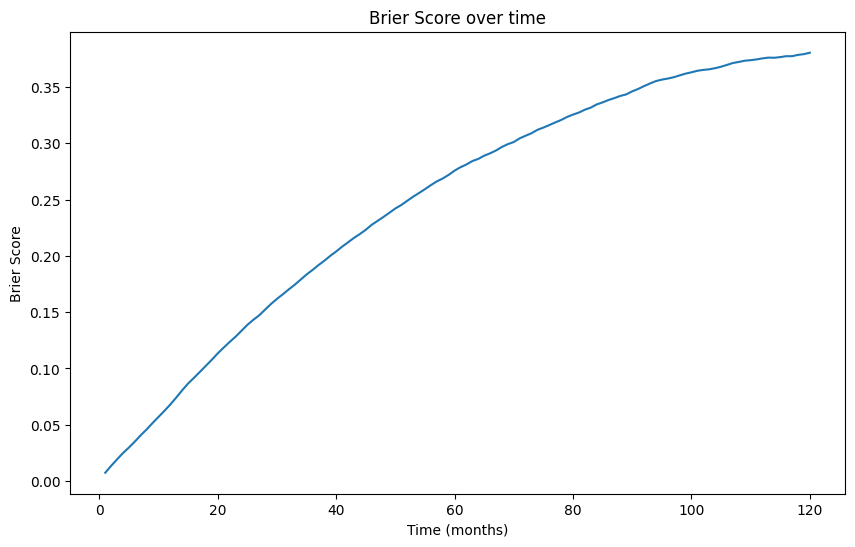

In [ ]:
# Standardize predicted risk scores using StandardScaler to ensure zero mean and unit variance
scaler = StandardScaler()
surv_risks_scaled = scaler.fit_transform(y_pred.reshape(-1, 1)).flatten()

# Convert standardized risk scores to hazard ratios using exponential transformation
hazard_ratio = np.exp(surv_risks_scaled)

# Calculate Kaplan-Meier survival probabilities for the training data
time_train, survival_prob_train = kaplan_meier_estimator(
    y_train["event"],
    y_train["time"]
)

# Compute baseline hazard by taking the negative log of survival probabilities (add small epsilon to avoid log(0))
# Replace NaN/Inf values with 0 to ensure numerical stability
baseline_hazard = -np.log(survival_prob_train + 1e-8)
baseline_hazard = np.nan_to_num(baseline_hazard, nan=0.0, posinf=0.0)

# Calculate survival probabilities for test data using hazard ratios and baseline hazard
survival_probs_test = np.exp(-hazard_ratio[:, np.newaxis] * baseline_hazard)

# Define time points for evaluation (1 to 120 months)
time_points = np.arange(1, 121, 1)

# Create interpolation function for survival probabilities using the training time grid
# Uses "previous" interpolation to align with stepwise nature of survival curves
interp_func = interp1d(
    time_train,
    survival_probs_test,
    kind='previous',
    axis=1,
    bounds_error=False,
    fill_value=(1.0, 0.0)  # Extend with 1.0 (survival) before first time point and 0.0 after last
)

# Interpolate survival probabilities to predefined monthly time points
surv_probs_interp = interp_func(time_points)
surv_probs_interp = np.minimum.accumulate(surv_probs_interp, axis=1)

# Clip survival probabilities to valid [0.0, 1.0] range
surv_probs_final = np.clip(surv_probs_interp, 0.0, 1.0)

# Calculate the Brier Score at the specified time points
brier_scores = brier_score(
    y_train,  # Training data used to estimate censoring
    y_test,   # Test data
    surv_probs_final,
    time_points
)

# Calculate the Integrated Brier Score (IBS) over the entire time range
ibs = integrated_brier_score(
    y_train,  # Training data used to estimate censoring
    y_test,   # Test data
    surv_probs_final,
    time_points
)

# Print the Brier Score at specific time points: 12, 36, 60, 84, and 120 months
print(f"Brier Score at 12 months: {brier_scores[1][11]}")
print(f"Brier Score at 36 months: {brier_scores[1][35]}")
print(f"Brier Score at 60 months: {brier_scores[1][59]}")
print(f"Brier Score at 84 months: {brier_scores[1][83]}")
print(f"Brier Score at 120 months: {brier_scores[1][119]}")
print(f"\nIntegrated Brier Score (IBS): {ibs}")

# Plot the Brier Score over time
plt.figure(figsize=(10, 6))
plt.plot(time_points, brier_scores[1])
plt.xlabel("Time (months)")
plt.ylabel("Brier Score")
plt.title("Brier Score over time")
plt.show()

In [ ]:
# Best features by permutation importance
calculate_permutation_importance_xgb(best, X_test, y_test, feat_cols, random_state=seed)  # Calculate permutation importance of features for the best model

,importances_mean,importances_std
IBGE,-0.000331,0.000181
DRS,-0.001000,0.000177
ESCOLARI,-0.001164,0.000267
DRS_INST,-0.002086,0.000251
MORFO,-0.002404,0.000287
DIAGPREV,-0.002818,0.000430
HABILIT2,-0.003028,0.000245
IBGEATEN,-0.004655,0.000526
DIAGTRAT_CAT,-0.006539,0.000576
INSTITU,-0.007523,0.000578


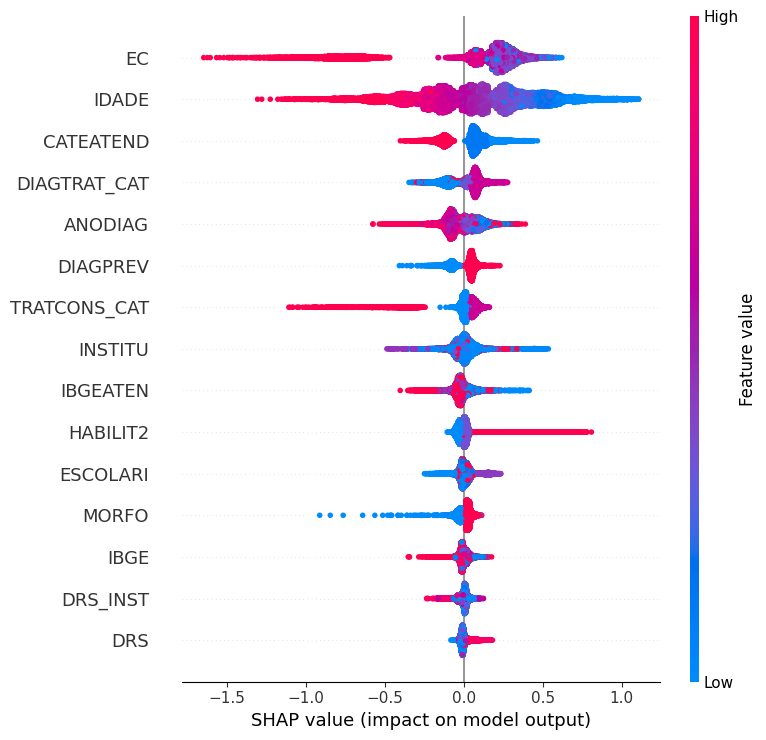

In [ ]:
# Create a SHAP TreeExplainer for the best model
explainer = shap.TreeExplainer(best)

# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test)

# Generate a summary plot to visualize the SHAP values for each feature
shap.summary_plot(shap_values, X_test, feature_names=feat_cols)

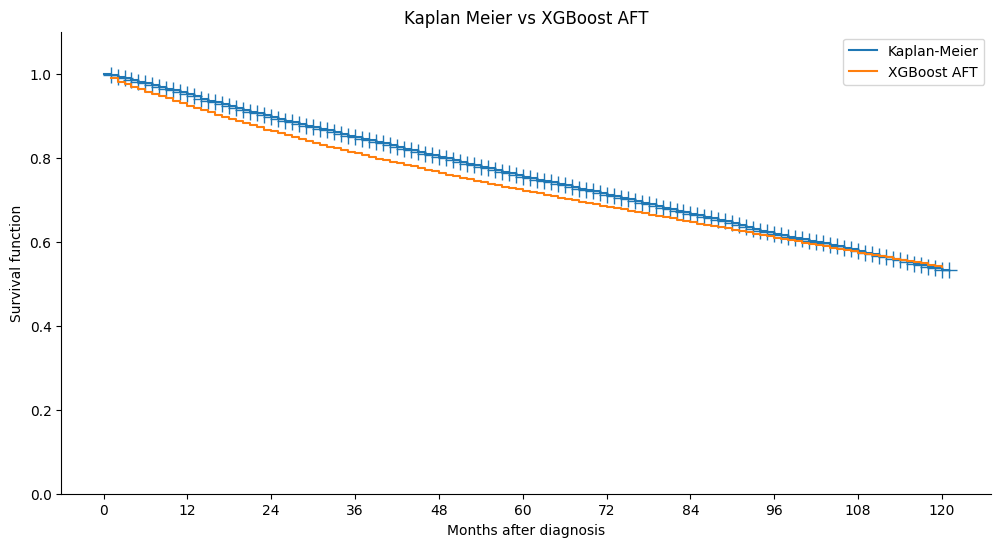

In [ ]:
# Survival Curve Plotting
name = 'XGBoost AFT'
fig = plt.figure(figsize=(12, 6))  # Create the plot figure
ax = plt.subplot(111)  # Create the axes for the plot

# Kaplan-Meier Comparison (if enabled)
E = (df_teste.obito_geral == 1)  # Extract event data (death)
T = df_teste.meses_diag  # Extract time-to-event data (months since diagnosis)

kmf = KaplanMeierFitter()  # Initialize Kaplan-Meier model
ax = kmf.fit(T, E).plot_survival_function(ax=ax, ci_show=False,  # Fit and plot Kaplan-Meier survival curve
                                          show_censors=True,  # Show censoring events
                                          label='Kaplan-Meier')  # Set label for the curve
title = f'Kaplan Meier vs {name}'  # Set title for comparison plot

# Plotting Model Survival Curve
surv_mean = surv_probs_final.mean(axis=0)  # Compute the mean survival function across all samples
ax.step(time_points, surv_mean, where='post', label=name)  # Plot the model's survival curve

# Plot Formatting
ax.set_title(title)  # Set the plot title
ax.set_xlabel('Months after diagnosis')  # Set x-axis label
ax.set_ylabel('Survival function')  # Set y-axis label
ax.spines['top'].set_visible(False)  # Remove top border
ax.spines['right'].set_visible(False)  # Remove right border
plt.xticks(np.arange(0, time_points[-1] + 11, 12))  # Set x-axis ticks every 12 months
plt.ylim([0, 1.1])  # Set y-axis limits
plt.legend();  # Show the legend

### **LightGBM**

#### **Base Model**

In [ ]:
# LightGBM Model
dtrain = lgb.Dataset(X_train, label=y_train['time'],
                     weight=np.where(y_train['event'], 1.0, 0.2))  # Create a LightGBM dataset with event weights

# Define model parameters
params = {
    'objective': 'regression',  # LightGBM does not have direct survival support, using regression as a proxy
    'metric': 'rmse',           # Metric for monitoring (not used for survival analysis)
    'max_depth': 7,             # Maximum depth of trees
    'seed': seed,               # Set random seed for reproducibility
    'verbose': -1,              # Suppress output during training
    'n_jobs': -1                # Use all CPU cores for training
}

# Train the model
lgbm = lgb.train(params, dtrain, num_boost_round=100)  # Train the LightGBM model with 100 boosting rounds

# Make predictions (risk scores)
y_pred = lgbm.predict(X_test)  # Predict risk scores on the test data

# Evaluate the model using the C-Index (Test data)
c_index_base = concordance_index_censored(y_test['event'], y_test['time'], -y_pred)[0]  # Calculate C-Index for test data

# Evaluate the model using the C-Index (Train data)
y_pred_train = lgbm.predict(X_train)  # Predict risk scores on the training data
c_index_train = concordance_index_censored(y_train['event'], y_train['time'], -y_pred_train)[0]  # Calculate C-Index for training data

# Display the results
print(f'C-index Test: {c_index_base}')  # Print the C-Index for test data
print(f'C-index Train: {c_index_train}')  # Print the C-Index for train data

C-index Test: 0.6837949941098503
C-index Train: 0.6903251726759692


In [ ]:
# C-Index IPCW (Inverse Probability of Censoring Weight)
surv_risks = lgbm.predict(X_test)  # Predict survival risks for the test data
surv_risks_train = lgbm.predict(X_train)  # Predict survival risks for the training data

# Calculate the C-Index using IPCW for test data
c_index_ipcw = concordance_index_ipcw(y_train, y_test, -surv_risks)  # Evaluate the concordance index for test data

# Calculate the C-Index using IPCW for training data
c_index_ipcw_train = concordance_index_ipcw(y_train, y_train, -surv_risks_train)  # Evaluate the concordance index for training data

# Display the results for C-Index IPCW
print(f'C-Index IPCW Test: {c_index_ipcw[0]}')  # Print the IPCW C-Index for test data
print(f'C-Index IPCW Train: {c_index_ipcw_train[0]}')  # Print the IPCW C-Index for train data

C-Index IPCW Test: 0.6721662820928223
C-Index IPCW Train: 0.6782727026540646


#### **Optuna**

In [ ]:
# Optuna number of trials
n_trials = 150

In [ ]:
# Folds for cross-validation
kf = KFold(10, shuffle=True, random_state=seed)  # Split the data into 10 folds, shuffle data and set a random seed

# Objective function for hyperparameter optimization
def objective(trial):
    # Define the hyperparameters to be optimized
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 150),  # Number of trees in the model
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.25, step=0.01),  # Learning rate for boosting
        'max_depth': trial.suggest_int('max_depth', 3, 8),  # Maximum depth of the trees
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),  # Number of leaves in each tree
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 20),  # Minimum samples for each child node
        'subsample': trial.suggest_float('subsample', 0.5, 1.0, step=0.05),  # Subsample ratio for training
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0, step=0.05),  # Column sampling ratio for each tree
        'reg_alpha': trial.suggest_categorical('reg_alpha', [1e-4, 1e-3, 1e-2, 1e-1, 1, 10.0]),  # L1 regularization term
        'reg_lambda': trial.suggest_categorical('reg_lambda', [1e-4, 1e-3, 1e-2, 1e-1, 1, 10.0]),  # L2 regularization term
        'objective': 'regression',  # Set objective to regression (using Cox regression as a proxy)
        'metric': 'rmse',  # Metric for evaluation (Root Mean Squared Error)
        'seed': seed,  # Random seed
        'verbose': -1,  # Suppress output during training
        'n_jobs': -1  # Use all available CPU cores for parallel computation
    }

    c_index_list = []  # Initialize an empty list to store the C-Index scores for each fold

    # Loop through the folds for cross-validation
    for train_idx, valid_idx in kf.split(X_train):
        # Split the data into training and validation sets based on the current fold
        X_t, X_v = X_train[train_idx], X_train[valid_idx]  # Training and validation features
        y_t, y_v = y_train[train_idx], y_train[valid_idx]  # Training and validation target labels

        # Create DMatrix for training data, using weights based on event occurrence
        dtrain = lgb.Dataset(X_t, label=y_t['time'], weight=np.where(y_t['event'], 1.0, 0.2))

        # Train the model using the current hyperparameters
        model = lgb.train(param, dtrain, num_boost_round=100)

        # Make predictions on the validation set
        pred_valid = model.predict(X_v)

        # Calculate the Concordance Index for the validation fold
        c_index = concordance_index_censored(y_v['event'], y_v['time'], -pred_valid)[0]
        c_index_list.append(c_index)  # Append the C-Index score to the list

    # Return the mean C-Index across all folds
    return np.mean(c_index_list)

**RandomSampler**

In [ ]:
# Hyperparameter optimization with Optuna - RandomSampler
study = optuna.create_study(direction='maximize', sampler=RandomSampler(seed),  # Create an Optuna study with a random sampler for optimization
                            study_name='LGBM_RandomSampler')  # Name the study for identification

study.optimize(objective, n_trials=n_trials, n_jobs=-1)  # Optimize the objective function using a random sampler

In [ ]:
# Display the best hyperparameters found during the optimization process
print('Best parameters:', study.best_params)

Best parameters: {'n_estimators': 147, 'learning_rate': 0.11, 'max_depth': 8, 'num_leaves': 86, 'min_child_samples': 11, 'subsample': 0.5, 'colsample_bytree': 0.5, 'reg_alpha': 0.001, 'reg_lambda': 0.01}


In [ ]:
# Training and evaluation with the best hyperparameters
weights = np.where(y_train['event'], 1.0, 0.2)  # Assign weights based on event occurrence (1.0 for events, 0.15 for censored data)

# Update the best parameters with the required model settings
best_params = study.best_params
best_params.update({'objective': 'regression',  # Use regression (Cox model) for survival analysis
                    'metric': 'rmse',  # Metric for monitoring performance (Root Mean Squared Error)
                    'seed': seed,  # Set the random seed for reproducibility
                    'verbose': -1,  # Suppress output during training
                    'n_jobs': -1})  # Use all available CPU cores for parallel computation

# Create the LightGBM dataset using the training data and weights
dtrain = lgb.Dataset(X_train, label=y_train['time'], weight=weights)
# dtest = xgb.DMatrix(X_test)  # You could use this for testing if needed, but it's not used here

# Train the LightGBM model with the best parameters found by Optuna
lgbm_rand = lgb.train(best_params, dtrain, num_boost_round=100)

# Make predictions on the validation and training sets
y_pred = lgbm_rand.predict(X_test)  # Predictions for the test set
y_pred_train = lgbm_rand.predict(X_train)  # Predictions for the training set

# Calculate the Concordance Index (C-Index) for the test set
c_index_rand = concordance_index_censored(y_test['event'], y_test['time'], -y_pred)[0]
c_index_rand_train = concordance_index_censored(y_train['event'], y_train['time'], -y_pred_train)[0]

# Display the C-Index for both test and training sets
print(f'C-Index Test: {c_index_rand}')
print(f'C-Index Train: {c_index_rand_train}')

C-Index Test: 0.6847559751882069
C-Index Train: 0.7119335325381787


**TPESampler**

In [ ]:
# Hyperparameter optimization with Optuna - TPESampler
study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=seed),  # Create an Optuna study using the TPE sampler for optimization
                            study_name='LGBM_TPESampler')  # Name the study for easier identification

study.optimize(objective, n_trials=n_trials, n_jobs=-1)  # Optimize the objective function using TPE with specified trials and parallel jobs

In [ ]:
# Display the best hyperparameters found by Optuna
print('Best parameters:', study.best_params)

Best parameters: {'n_estimators': 146, 'learning_rate': 0.09, 'max_depth': 7, 'num_leaves': 86, 'min_child_samples': 18, 'subsample': 0.5, 'colsample_bytree': 0.5, 'reg_alpha': 10.0, 'reg_lambda': 0.001}


In [ ]:
# Training and evaluation with the best hyperparameters
weights = np.where(y_train['event'], 1.0, 0.2)  # Assign weights based on event occurrence (1.0 for events, 0.15 for censored data)

# Update the best parameters with the necessary model settings
best_params = study.best_params
best_params.update({'objective': 'regression',  # Using Cox regression for survival analysis
                    'metric': 'rmse',  # Root Mean Squared Error metric for monitoring performance
                    'seed': seed,  # Set the random seed for reproducibility
                    'verbose': -1,  # Suppress output during training
                    'n_jobs': -1})  # Use all available CPU cores for parallel computation

# Create the LightGBM dataset using the training data and weights
dtrain = lgb.Dataset(X_train, label=y_train['time'], weight=weights)
# dtest = xgb.DMatrix(X_test)  # You could use this for testing, but it's not utilized in the current context

# Train the LightGBM model with the best parameters found by Optuna
lgbm_tpe = lgb.train(best_params, dtrain, num_boost_round=100)

# Make predictions on both the validation and training sets
y_pred = lgbm_tpe.predict(X_test)  # Predictions for the test set
y_pred_train = lgbm_tpe.predict(X_train)  # Predictions for the training set

# Calculate the Concordance Index (C-Index) for the test set
c_index_tpe = concordance_index_censored(y_test['event'], y_test['time'], -y_pred)[0]
c_index_tpe_train = concordance_index_censored(y_train['event'], y_train['time'], -y_pred_train)[0]

# Display the C-Index for both the test and training sets
print(f'C-Index Test: {c_index_tpe}')
print(f'C-Index Train: {c_index_tpe_train}')

C-Index Test: 0.6858108946645116
C-Index Train: 0.7029272100420927


**CmaEsSampler**

In [ ]:
# Hyperparameter optimization with Optuna - CmaEsSampler
study = optuna.create_study(direction='maximize', sampler=CmaEsSampler(seed=seed),  # Create an Optuna study using the CMA-ES sampler for optimization
                            study_name='LGBM_CmaEsSampler')  # Name the study for easier identification

study.optimize(objective, n_trials=n_trials, n_jobs=-1)  # Optimize the objective function using CMA-ES with specified trials and parallel jobs

In [ ]:
# Display the best hyperparameters found by Optuna
print('Best parameters:', study.best_params)

Best parameters: {'n_estimators': 138, 'learning_rate': 0.09, 'max_depth': 7, 'num_leaves': 87, 'min_child_samples': 8, 'subsample': 0.5, 'colsample_bytree': 0.55, 'reg_alpha': 10.0, 'reg_lambda': 0.01}


In [ ]:
# Training and evaluation with the best hyperparameters
weights = np.where(y_train['event'], 1.0, 0.2)  # Assign weights based on event occurrence (1.0 for events, 0.15 for censored data)

# Update the best parameters with the necessary model settings
best_params = study.best_params
best_params.update({'objective': 'regression',  # Using Cox regression for survival analysis
                    'metric': 'rmse',  # Root Mean Squared Error metric for monitoring performance
                    'seed': seed,  # Set the random seed for reproducibility
                    'verbose': -1,  # Suppress output during training
                    'n_jobs': -1})  # Use all available CPU cores for parallel computation

# Create the LightGBM dataset using the training data and weights
dtrain = lgb.Dataset(X_train, label=y_train['time'], weight=weights)
# dtest = xgb.DMatrix(X_test)  # You could use this for testing, but it's not utilized in the current context

# Train the LightGBM model with the best parameters found by Optuna
lgbm_cma = lgb.train(best_params, dtrain, num_boost_round=100)

# Make predictions on both the validation and training sets
y_pred = lgbm_cma.predict(X_test)  # Predictions for the test set
y_pred_train = lgbm_cma.predict(X_train)  # Predictions for the training set

# Calculate the Concordance Index (C-Index) for the test set
c_index_cma = concordance_index_censored(y_test['event'], y_test['time'], -y_pred)[0]
c_index_cma_train = concordance_index_censored(y_train['event'], y_train['time'], -y_pred_train)[0]

# Display the C-Index for both the test and training sets
print(f'C-Index Test: {c_index_cma}')
print(f'C-Index Train: {c_index_cma_train}')

C-Index Test: 0.6861813437932488
C-Index Train: 0.7047337897880533


#### **Best LightGBM Model**

In [ ]:
# Best LightGBM Model Selection
scores = [c_index_base, c_index_rand, c_index_tpe, c_index_cma]  # List of C-Index scores for each model (base, random, TPE, CMA-ES)
models = [lgbm, lgbm_rand, lgbm_tpe, lgbm_cma]  # List of LightGBM models corresponding to each hyperparameter optimization approach

# Identify the model with the highest C-Index score
id_best_score = scores.index(max(scores))  # Find the index of the highest C-Index score
best = models[id_best_score]  # Select the model corresponding to the best score

# Display the best model
print(best)

In [ ]:
# Make predictions on the validation and training sets
y_pred = best.predict(X_test)  # Predict survival risks on the test set using the best model
y_pred_train = best.predict(X_train)  # Predict survival risks on the training set using the best model

# Calculate C-Index for the test set
final_c_index = concordance_index_censored(y_test['event'], y_test['time'], -y_pred)[0]  # Compute the concordance index for the test set
final_c_index_train = concordance_index_censored(y_train['event'], y_train['time'], -y_pred_train)[0]  # Compute the concordance index for the training set

# Display C-Index results
print('C-Index')
print(f'> Test: {final_c_index}')  # Print the C-Index for the test set
print(f'> Train: {final_c_index_train}')  # Print the C-Index for the training set

# Calculate IPCW C-Index
c_index_ipcw = concordance_index_ipcw(y_train, y_test, -y_pred)  # Compute IPCW C-Index for the test set
c_index_ipcw_train = concordance_index_ipcw(y_train, y_train, -y_pred_train)  # Compute IPCW C-Index for the training set

# Display IPCW C-Index results
print('\nC-Index IPCW')
print(f'> Test: {c_index_ipcw[0]}')  # Print IPCW C-Index for the test set
print(f'> Train: {c_index_ipcw_train[0]}')  # Print IPCW C-Index for the training set

C-Index
> Test: 0.6861813437932488
> Train: 0.7047337897880533

C-Index IPCW
> Test: 0.674224207397505
> Train: 0.6879910839788079


Brier Score at 12 months: 0.054550462151106434
Brier Score at 36 months: 0.19260121047393436
Brier Score at 60 months: 0.3170627442583789
Brier Score at 84 months: 0.41265780073395775
Brier Score at 120 months: 0.465028669766681

Integrated Brier Score (IBS): 0.289103502439545


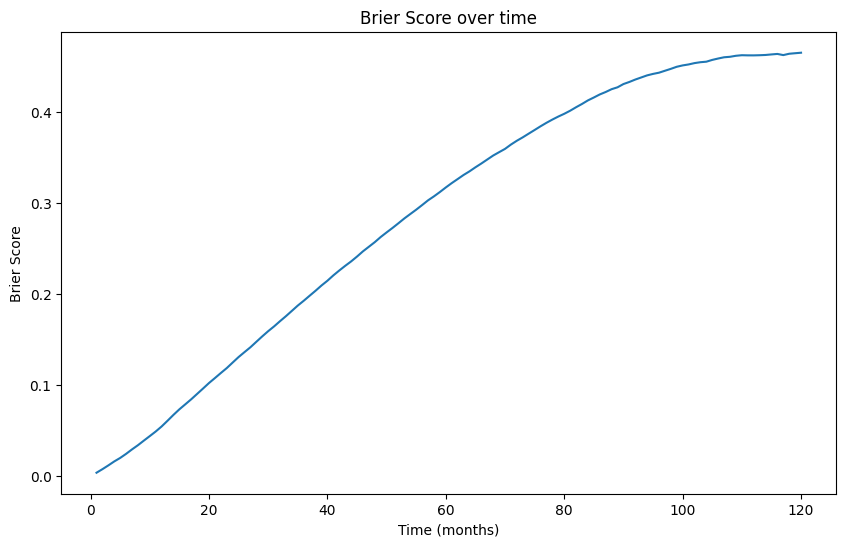

In [ ]:
# Standardize predicted risk scores using StandardScaler to ensure zero mean and unit variance
scaler = StandardScaler()
surv_risks_scaled = scaler.fit_transform(y_pred.reshape(-1, 1)).flatten()

# Convert standardized risk scores to hazard ratios using exponential transformation
hazard_ratio = np.exp(surv_risks_scaled)

# Calculate Kaplan-Meier survival probabilities for the training data
time_train, survival_prob_train = kaplan_meier_estimator(
    y_train["event"],
    y_train["time"]
)

# Compute baseline hazard by taking the negative log of survival probabilities (add small epsilon to avoid log(0))
# Replace NaN/Inf values with 0 to ensure numerical stability
baseline_hazard = -np.log(survival_prob_train + 1e-8)
baseline_hazard = np.nan_to_num(baseline_hazard, nan=0.0, posinf=0.0)

# Calculate survival probabilities for test data using hazard ratios and baseline hazard
survival_probs_test = np.exp(-hazard_ratio[:, np.newaxis] * baseline_hazard)

# Define time points for evaluation (1 to 120 months)
time_points = np.arange(1, 121, 1)

# Create interpolation function for survival probabilities using the training time grid
# Uses "previous" interpolation to align with stepwise nature of survival curves
interp_func = interp1d(
    time_train,
    survival_probs_test,
    kind='previous',
    axis=1,
    bounds_error=False,
    fill_value=(1.0, 0.0)  # Extend with 1.0 (survival) before first time point and 0.0 after last
)

# Interpolate survival probabilities to predefined monthly time points
surv_probs_interp = interp_func(time_points)
surv_probs_interp = np.minimum.accumulate(surv_probs_interp, axis=1)

# Clip survival probabilities to valid [0.0, 1.0] range
surv_probs_final = np.clip(surv_probs_interp, 0.0, 1.0)

# Calculate the Brier Score at the specified time points
brier_scores = brier_score(
    y_train,  # Training data used to estimate censoring
    y_test,   # Test data
    surv_probs_final,
    time_points
)

# Calculate the Integrated Brier Score (IBS) over the entire time range
ibs = integrated_brier_score(
    y_train,  # Training data used to estimate censoring
    y_test,   # Test data
    surv_probs_final,
    time_points
)

# Print the Brier Score at specific time points: 12, 36, 60, 84, and 120 months
print(f"Brier Score at 12 months: {brier_scores[1][11]}")
print(f"Brier Score at 36 months: {brier_scores[1][35]}")
print(f"Brier Score at 60 months: {brier_scores[1][59]}")
print(f"Brier Score at 84 months: {brier_scores[1][83]}")
print(f"Brier Score at 120 months: {brier_scores[1][119]}")
print(f"\nIntegrated Brier Score (IBS): {ibs}")

# Plot the Brier Score over time
plt.figure(figsize=(10, 6))
plt.plot(time_points, brier_scores[1])
plt.xlabel("Time (months)")
plt.ylabel("Brier Score")
plt.title("Brier Score over time")
plt.show()

In [ ]:
# Best features by permutation importance
calculate_permutation_importance_lgbm(best, X_test, y_test, feat_cols, random_state=seed)  # Calculate permutation importance of features for the best model

,importances_mean,importances_std
EC,0.078639,0.001247
IDADE,0.041868,0.000624
ANODIAG,0.035362,0.002533
CATEATEND,0.028736,0.001008
DIAGTRAT_CAT,0.012341,0.000571
TRATCONS_CAT,0.011369,0.000558
INSTITU,0.011337,0.000788
DIAGPREV,0.004730,0.000365
MORFO,0.003688,0.000406
IBGEATEN,0.003664,0.000391


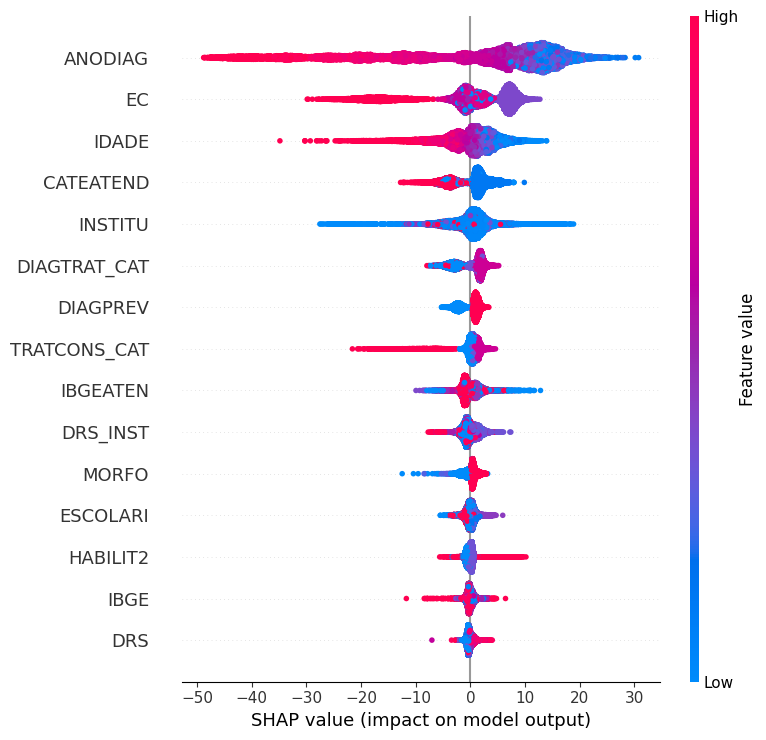

In [ ]:
# Create a SHAP TreeExplainer for the best model
explainer = shap.TreeExplainer(best)

# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test)

# Generate a summary plot to visualize the SHAP values for each feature
shap.summary_plot(shap_values, X_test, feature_names=feat_cols)

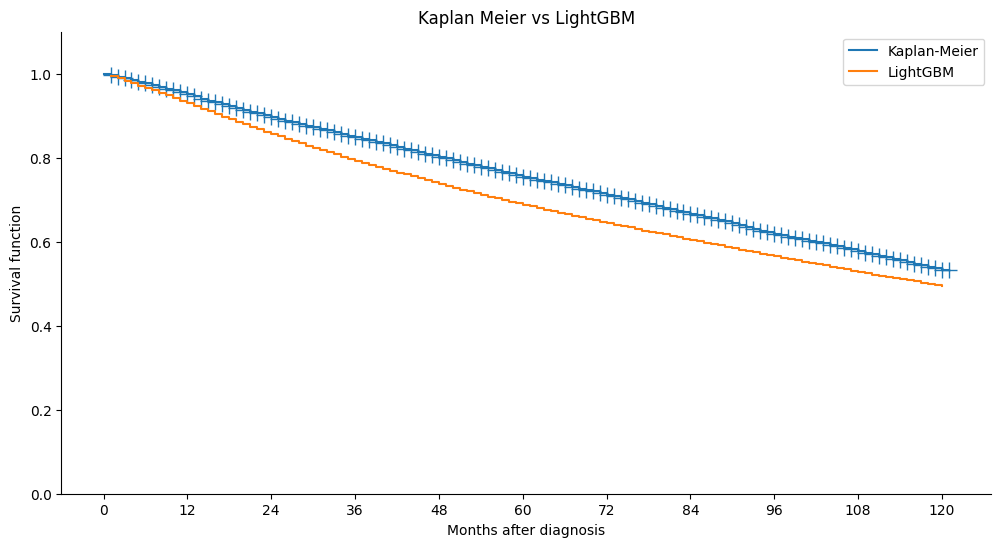

In [ ]:
# Survival Curve Plotting
name = 'LightGBM'
fig = plt.figure(figsize=(12, 6))  # Create the plot figure
ax = plt.subplot(111)  # Create the axes for the plot

# Kaplan-Meier Comparison (if enabled)
E = (df_teste.obito_geral == 1)  # Extract event data (death)
T = df_teste.meses_diag  # Extract time-to-event data (months since diagnosis)

kmf = KaplanMeierFitter()  # Initialize Kaplan-Meier model
ax = kmf.fit(T, E).plot_survival_function(ax=ax, ci_show=False,  # Fit and plot Kaplan-Meier survival curve
                                          show_censors=True,  # Show censoring events
                                          label='Kaplan-Meier')  # Set label for the curve
title = f'Kaplan Meier vs {name}'  # Set title for comparison plot

# Plotting Model Survival Curve
surv_mean = surv_probs_final.mean(axis=0)  # Compute the mean survival function across all samples
ax.step(time_points, surv_mean, where='post', label=name)  # Plot the model's survival curve

# Plot Formatting
ax.set_title(title)  # Set the plot title
ax.set_xlabel('Months after diagnosis')  # Set x-axis label
ax.set_ylabel('Survival function')  # Set y-axis label
ax.spines['top'].set_visible(False)  # Remove top border
ax.spines['right'].set_visible(False)  # Remove right border
plt.xticks(np.arange(0, time_points[-1] + 11, 12))  # Set x-axis ticks every 12 months
plt.ylim([0, 1.1])  # Set y-axis limits
plt.legend();  # Show the legend